# EDA

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

Importación datos

In [2]:
from pathlib import Path

DATA_DIR = Path("datos")

OHLCV_WIDE_PATH = DATA_DIR / "precios_ohlcv_wide.csv"

print(OHLCV_WIDE_PATH)
# Cargar precios OHLCV en formato horizontal
ohlcv_wide = pd.read_csv(OHLCV_WIDE_PATH, parse_dates=True)
ohlcv_wide = ohlcv_wide.set_index("Date")
print("\nPrecios OHLCV en formato horizontal:")
print(ohlcv_wide.head())




datos\precios_ohlcv_wide.csv

Precios OHLCV en formato horizontal:
            Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  Close_NVDA   Close_SPY  Close_TSLA  High_AMZN  High_GOOGL  High_META  High_MSFT  High_NVDA    High_SPY  High_TSLA   Low_AMZN  Low_GOOGL  \
Date                                                                                                                                                                                                   
2014-01-02   19.898500    27.627516   54.284016   30.694443    0.373844  148.580261   10.006667    19.9680   27.742432  54.790047  30.892686   0.376672  149.514378  10.165333  19.701000  27.506891   
2014-01-03   19.822001    27.425976   54.135174   30.487936    0.369365  148.555923    9.970667    20.1355   27.722076  55.216687  30.743999   0.375258  149.132640  10.146000  19.811001  27.424239   
2014-01-06   19.681499    27.731758   56.754623   29.843655    0.374315  148.125412    9.800000    19.8500   27.769980  56.814154  30

Establecemos que ticker vamos a usar

In [3]:
ohlcv_wide.columns = [str(col).strip() for col in ohlcv_wide.columns]

tickers = sorted([
    col.replace("Close_", "")
    for col in ohlcv_wide.columns
    if col.startswith("Close_")
])

print("Tickers detectados:")
print(tickers)

Tickers detectados:
['AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'SPY', 'TSLA']


Comprobamos máximos y mínimos viendo que todo está correcto 

In [4]:
ohlcv_wide.info()

summary_dates = pd.DataFrame({
    "Ticker": tickers,
    "min": [
        ohlcv_wide[f"Close_{ticker}"].dropna().index.min()
        for ticker in tickers
    ],
    "max": [
        ohlcv_wide[f"Close_{ticker}"].dropna().index.max()
        for ticker in tickers
    ],
    "count": [
        ohlcv_wide[f"Close_{ticker}"].dropna().count()
        for ticker in tickers
    ],
})

summary_dates

<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 2014-01-02 to 2024-06-28
Data columns (total 35 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close_AMZN    2640 non-null   float64
 1   Close_GOOGL   2640 non-null   float64
 2   Close_META    2640 non-null   float64
 3   Close_MSFT    2640 non-null   float64
 4   Close_NVDA    2640 non-null   float64
 5   Close_SPY     2640 non-null   float64
 6   Close_TSLA    2640 non-null   float64
 7   High_AMZN     2640 non-null   float64
 8   High_GOOGL    2640 non-null   float64
 9   High_META     2640 non-null   float64
 10  High_MSFT     2640 non-null   float64
 11  High_NVDA     2640 non-null   float64
 12  High_SPY      2640 non-null   float64
 13  High_TSLA     2640 non-null   float64
 14  Low_AMZN      2640 non-null   float64
 15  Low_GOOGL     2640 non-null   float64
 16  Low_META      2640 non-null   float64
 17  Low_MSFT      2640 non-null   float64
 18  Low_NVDA      2640

,Ticker,min,max,count
0,AMZN,2014-01-02,2024-06-28,2640
1,GOOGL,2014-01-02,2024-06-28,2640
2,META,2014-01-02,2024-06-28,2640
3,MSFT,2014-01-02,2024-06-28,2640
4,NVDA,2014-01-02,2024-06-28,2640
5,SPY,2014-01-02,2024-06-28,2640
6,TSLA,2014-01-02,2024-06-28,2640


## Análisis de precios

Aunque el gráfico de precios absolutos permite visualizar la evolución histórica de cada activo, no es adecuado para comparar directamente cuál ha sido mejor inversión. Cada acción parte de un nivel de precio distinto y puede haber sufrido splits, cambios corporativos o diferencias estructurales en su cotización. Por ello, un precio más alto no implica necesariamente mayor rentabilidad. Para comparar correctamente los activos es necesario transformar los precios en retornos porcentuales, precios normalizados con base 100 o rentabilidades acumuladas, ya que estas medidas muestran el crecimiento relativo de una inversión inicial equivalente en cada activo.

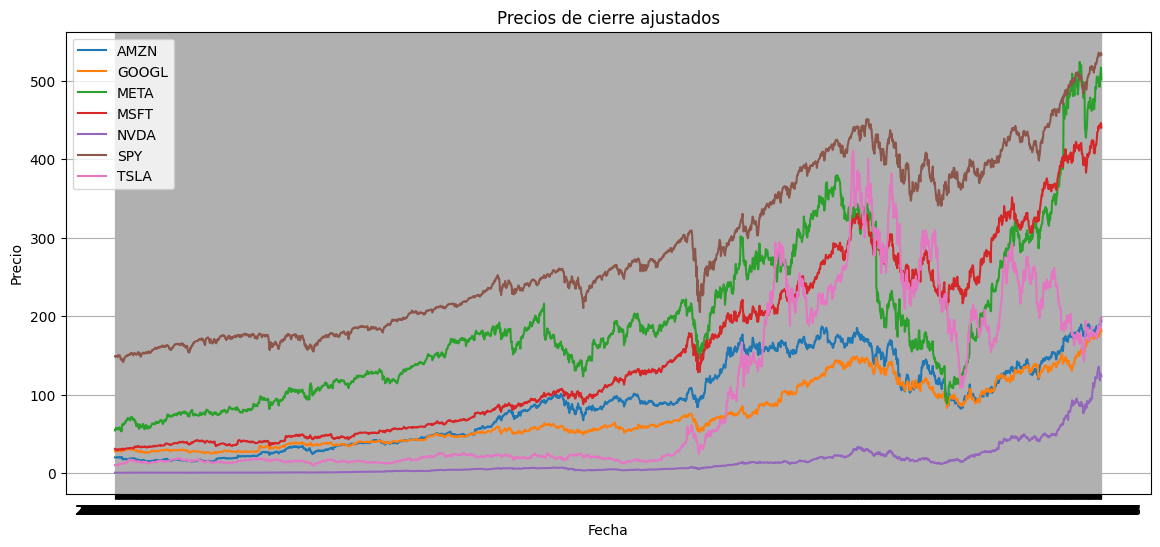

In [5]:
# Precios absolutos de cierre ajustados
plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(ohlcv_wide.index, ohlcv_wide[columna], label=ticker)

plt.title("Precios de cierre ajustados")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

En términos generales, normalizar una serie temporal permite comparar la evolución relativa de varios activos partiendo de una misma base inicial, por ejemplo 100. Esto elimina el problema de comparar precios absolutos, ya que todos los activos empiezan desde el mismo punto y se observa cuánto habría crecido una inversión equivalente en cada uno. Sin embargo, la normalización no siempre garantiza una comparación visual clara: si uno de los activos tiene un crecimiento extremadamente superior al resto, domina la escala del gráfico y hace que las demás series parezcan casi planas. Por tanto, los gráficos normalizados son útiles para interpretar crecimiento relativo, pero deben complementarse con tablas de rentabilidad, escala logarítmica, volatilidad y drawdown para obtener una comparación financiera más completa.

,Close_AMZN,Close_GOOGL,Close_META,Close_MSFT,Close_NVDA,Close_SPY,Close_TSLA,High_AMZN,High_GOOGL,High_META,High_MSFT,High_NVDA,High_SPY,High_TSLA,Low_AMZN,Low_GOOGL,Low_META,Low_MSFT,Low_NVDA,Low_SPY,Low_TSLA,Open_AMZN,Open_GOOGL,Open_META,Open_MSFT,Open_NVDA,Open_SPY,Open_TSLA,Volume_AMZN,Volume_GOOGL,Volume_META,Volume_MSFT,Volume_NVDA,Volume_SPY,Volume_TSLA
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2014-01-03,99.615549,99.270510,99.725809,99.327218,98.802044,99.983620,99.640237,100.838840,99.926627,100.778681,99.518700,99.624550,99.744681,99.809816,100.558350,99.699525,100.627400,98.652275,99.363890,100.082226,101.398836,99.872110,99.958755,100.346501,99.598384,99.811578,99.592367,100.133511,103.386659,91.506533,88.542094,101.640757,99.707796,68.031352,75.867753
2014-01-06,98.909461,100.377313,104.551262,97.228201,100.126123,99.693870,97.934707,99.409054,100.099301,103.694297,98.636354,100.125168,99.722939,98.635892,98.578749,99.835776,99.741640,97.331538,99.745556,99.780814,99.106104,99.260276,99.780363,99.252217,98.661308,99.434683,99.733685,100.133511,148.311348,97.139563,159.397622,142.345963,157.441213,90.296723,86.631439
2014-01-07,100.015078,102.312414,105.867277,97.981678,101.765466,100.306161,99.506983,99.777142,101.962868,106.030399,97.566823,101.376736,99.847894,98.635892,100.068526,101.163981,105.591421,97.601057,101.335898,100.257581,99.112927,99.057173,100.855249,105.234337,97.269063,100.753785,99.516270,98.544727,89.624848,140.144943,178.739452,116.879623,128.142350,72.004708,81.347360
2014-01-08,100.992538,102.525327,106.433895,96.232460,103.152634,100.328015,100.786133,100.911454,102.645489,105.776860,96.630966,102.878643,99.869611,100.800113,100.512663,102.258493,105.609863,95.902930,102.671796,100.224684,101.508006,99.917249,102.737882,105.051943,96.385502,101.758838,99.711925,99.365819,108.359061,123.119578,131.222928,195.779931,118.493456,80.729524,99.592787


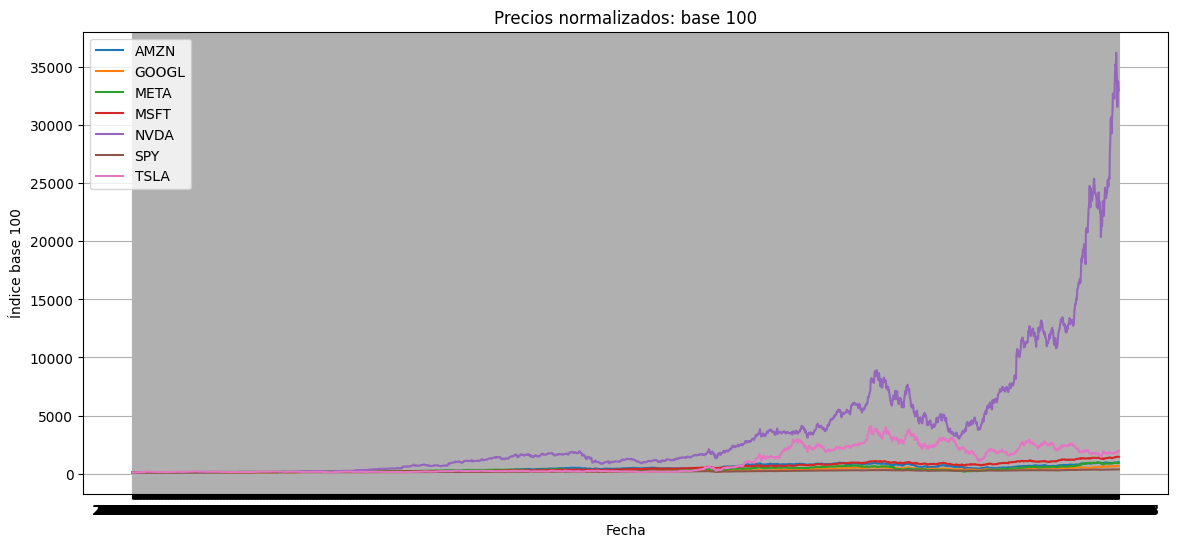

In [6]:
normalized_prices = ohlcv_wide / ohlcv_wide.iloc[0] * 100
display(normalized_prices.head())

plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(normalized_prices.index, normalized_prices[columna], label=ticker)

plt.title("Precios normalizados: base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.legend()
plt.show()

## Retornos simples

Los retornos simples miden cuánto ha cambiado el precio de un activo en porcentaje de un día al siguiente. No miran el cambio en dólares/euros, sino el cambio relativo. Por ejemplo, si una acción pasa de 100 a 105, el retorno simple es del 5%; si pasa de 100 a 95, el retorno es del -5%. En finanzas se usan más los retornos que los precios porque permiten comparar activos con precios muy distintos.

Formalmente:

retorno_t = Close_t / Close_{t-1} - 1

,count,mean,std,min,25%,50%,75%,max,mean_%,std_%,min_%,max_%
AMZN,2639.0,0.001075,0.020683,-0.140494,-0.008666,0.001078,0.011187,0.141311,0.107501,2.068266,-14.049438,14.131126
GOOGL,2639.0,0.000866,0.017576,-0.116342,-0.007388,0.001121,0.009400,0.162585,0.086628,1.757585,-11.634158,16.258450
META,2639.0,0.001126,0.023709,-0.263901,-0.009455,0.001097,0.012379,0.232824,0.112646,2.370855,-26.390086,23.282409
MSFT,2639.0,0.001151,0.016847,-0.147390,-0.006678,0.000868,0.009793,0.142169,0.115126,1.684656,-14.739037,14.216915
NVDA,2639.0,0.002628,0.029417,-0.187559,-0.011491,0.002386,0.016569,0.298067,0.262782,2.941682,-18.755873,29.806654
SPY,2639.0,0.000544,0.010876,-0.109424,-0.003673,0.000615,0.005757,0.090603,0.054355,1.087622,-10.942363,9.060314
TSLA,2639.0,0.001741,0.034983,-0.210628,-0.015703,0.001057,0.018313,0.198949,0.174125,3.498305,-21.062824,19.894859


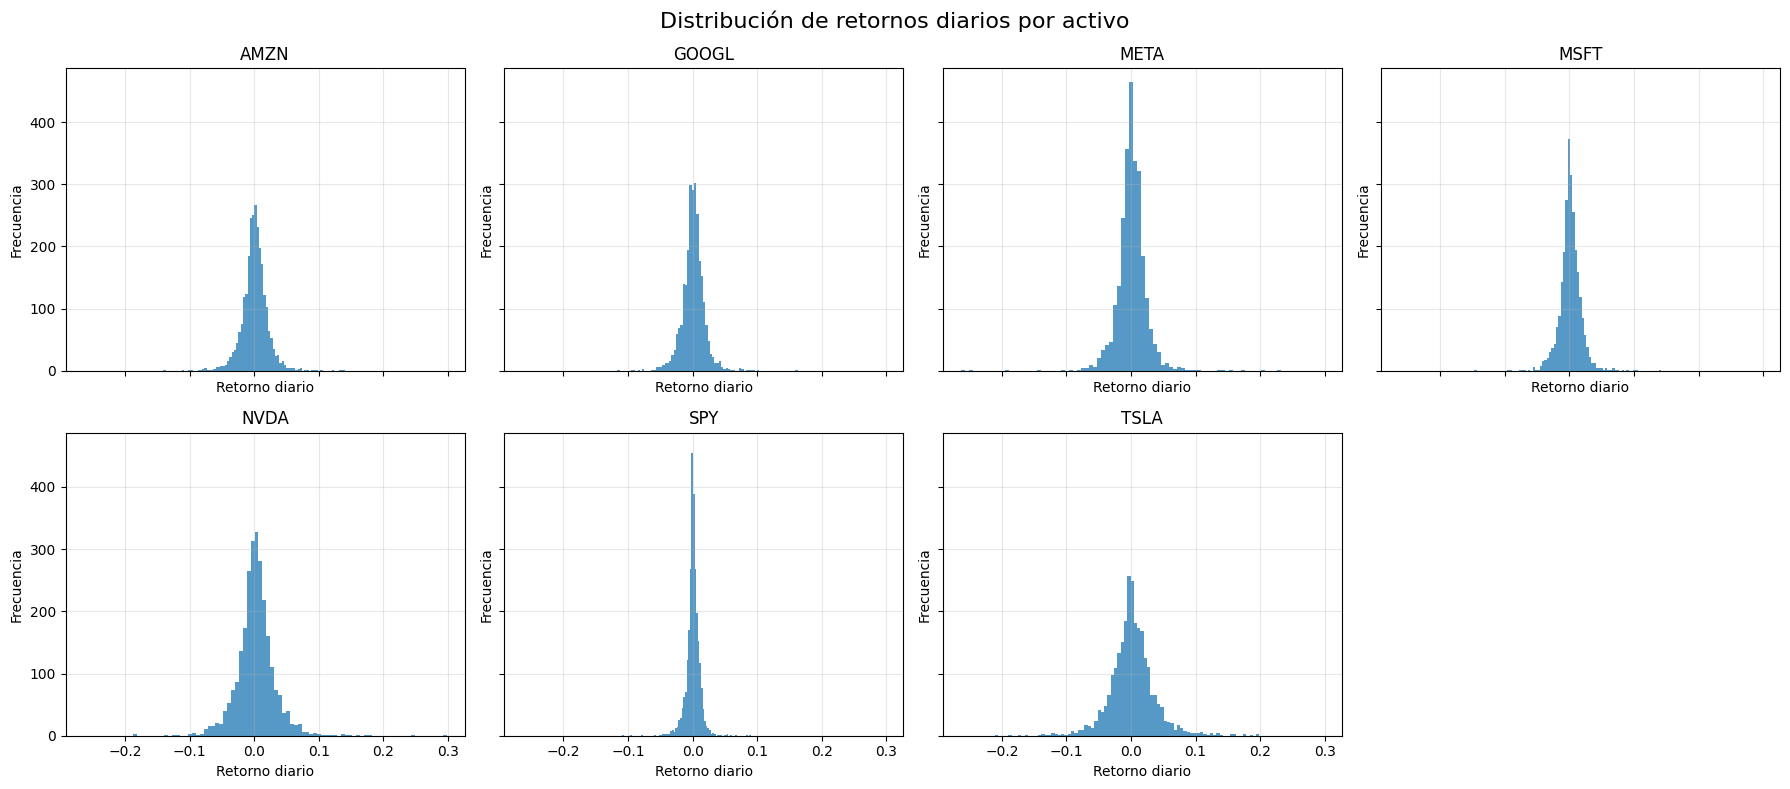

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\1673979546.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


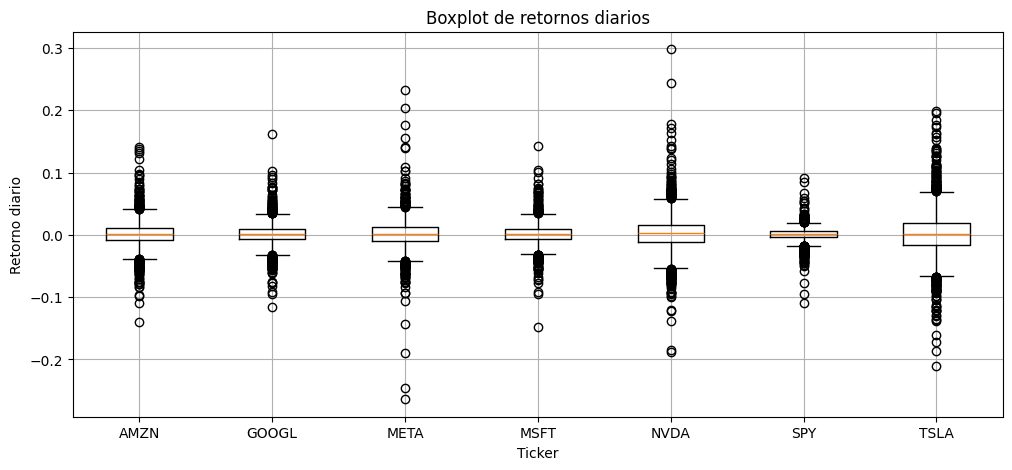

In [7]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

returns_wide = ohlcv_wide[close_cols].pct_change()
returns_wide.columns = tickers

returns_summary = returns_wide.describe().T

returns_summary["mean_%"] = returns_summary["mean"] * 100
returns_summary["std_%"] = returns_summary["std"] * 100
returns_summary["min_%"] = returns_summary["min"] * 100
returns_summary["max_%"] = returns_summary["max"] * 100

display(returns_summary)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].hist(
        returns_wide[ticker].dropna(),
        bins=80,
        alpha=0.75
    )
    axes[i].set_title(ticker)
    axes[i].set_xlabel("Retorno diario")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True, alpha=0.3)

for j in range(len(tickers), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribución de retornos diarios por activo", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(
    [returns_wide[ticker].dropna() for ticker in tickers],
    labels=tickers,
    showfliers=True
)
plt.title("Boxplot de retornos diarios")
plt.xlabel("Ticker")
plt.ylabel("Retorno diario")
plt.show()

## Retornos logarítmicos

Los retornos logarítmicos suelen preferirse en análisis financiero porque tienen una propiedad muy cómoda: son aditivos en el tiempo. Es decir, si calculas el retorno logarítmico de hoy, mañana y pasado, puedes sumarlos para obtener el retorno logarítmico total del periodo. Con los retornos simples esto no funciona así directamente, porque hay que multiplicar los factores de crecimiento. Por ejemplo, si un activo sube un 10% y luego baja un 10%, no vuelve exactamente al punto inicial: pasa de 100 a 110 y después a 99. Los retornos logarítmicos manejan mejor esta composición temporal y por eso son muy usados en modelos estadísticos, series temporales y análisis de volatilidad.

Además, los retornos logarítmicos suelen tener propiedades más convenientes para trabajar matemáticamente: son más simétricos para subidas y bajadas, se aproximan mucho al retorno simple cuando los cambios diarios son pequeños y tienden a comportarse mejor en ciertos modelos financieros. Dicho esto, no significa que los retornos simples estén mal. Para interpretar rentabilidades reales de una inversión, el retorno simple es más intuitivo: “he ganado un 5%”. Para modelar, agregar periodos y hacer análisis estadístico, el retorno logarítmico suele ser más limpio.

In [8]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

close_wide = ohlcv_wide[close_cols].copy()
close_wide.columns = tickers

log_returns_wide = np.log(close_wide / close_wide.shift(1))

ticker_example = "SPY"

comparison_returns = pd.DataFrame({
    "simple_return": returns_wide[ticker_example],
    "log_return": log_returns_wide[ticker_example]
})

comparison_returns["difference"] = (
    comparison_returns["simple_return"] - comparison_returns["log_return"]
)

display(comparison_returns.describe())

,simple_return,log_return,difference
count,2639.000000,2639.000000,2639.000000
mean,0.000544,0.000484,0.000060
std,0.010876,0.010913,0.000235
min,-0.109424,-0.115886,0.000000
25%,-0.003673,-0.003680,0.000002
50%,0.000615,0.000615,0.000011
75%,0.005757,0.005740,0.000046
max,0.090603,0.086731,0.006463


## Rentabilidad acumulada

Simular inversión inicial

In [9]:
cumulative_returns = (1 + returns_wide.fillna(0)).cumprod()

display(cumulative_returns.head())

,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Date,,,,,,,
2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2014-01-03,0.996155,0.992705,0.997258,0.993272,0.988020,0.999836,0.996402
2014-01-06,0.989095,1.003773,1.045513,0.972282,1.001261,0.996939,0.979347
2014-01-07,1.000151,1.023124,1.058673,0.979817,1.017655,1.003062,0.995070
2014-01-08,1.009925,1.025253,1.064339,0.962325,1.031526,1.003280,1.007861


,total_return,total_return_%
NVDA,329.299745,32929.974477
TSLA,18.774816,1877.481635
MSFT,13.335968,1333.596790
AMZN,8.711787,871.178710
META,8.235169,823.516888
GOOGL,5.546524,554.652406
SPY,2.587313,258.731343


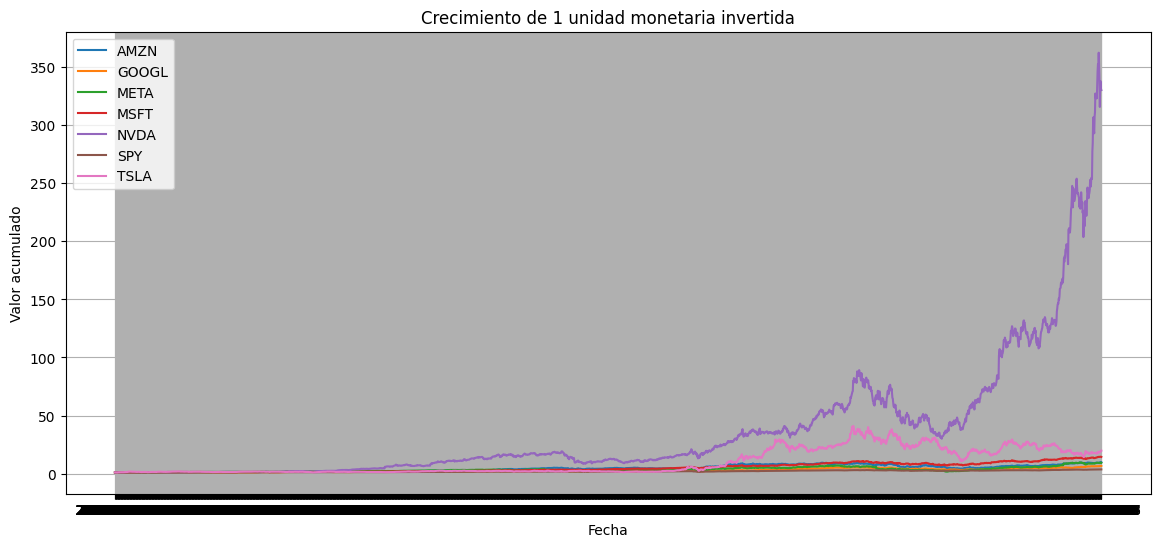

In [10]:
total_return = cumulative_returns.iloc[-1] - 1

total_return_df = pd.DataFrame({
    "total_return": total_return,
    "total_return_%": total_return * 100
}).sort_values("total_return_%", ascending=False)

display(total_return_df)

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Crecimiento de 1 unidad monetaria invertida")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado")
plt.legend()
plt.show()



## Medias móviles

Las medias móviles son una herramienta básica para suavizar una serie de precios y observar mejor su tendencia. En lugar de mirar únicamente el precio de hoy, que puede estar afectado por ruido diario, se calcula el promedio de los últimos N días. Por ejemplo, una media móvil de 20 días resume el comportamiento reciente del precio durante aproximadamente un mes bursátil. Esto permite distinguir mejor si el activo está siguiendo una tendencia alcista, bajista o lateral.

La idea intuitiva es sencilla: una media móvil corta, como la de 10 o 20 días, reacciona rápido a los cambios recientes del mercado; una media móvil larga, como la de 100 o 200 días, reacciona más lentamente y representa una tendencia más estructural. Por eso, cuando el precio está por encima de sus medias móviles, suele interpretarse como una señal de fortaleza; cuando está por debajo, puede interpretarse como debilidad. No es una regla infalible, pero ayuda a convertir el movimiento visual del precio en información cuantificable.

También se usan mucho los cruces de medias móviles. Si una media corta supera a una media larga, se suele interpretar como una posible señal de tendencia positiva, porque el precio reciente está ganando fuerza frente a su comportamiento de más largo plazo. Si ocurre lo contrario, puede interpretarse como pérdida de momentum. En un proyecto de Machine Learning financiero, las medias móviles no se usan solo para dibujar gráficos, sino también como variables: distancia del precio a la media, pendiente de la media, cruce entre medias o posición relativa del precio frente a distintos horizontes temporales. Así el modelo puede aprender patrones relacionados con tendencia y momentum.

,Close_AMZN,Close_GOOGL,Close_META,Close_MSFT,Close_NVDA,Close_SPY,Close_TSLA,High_AMZN,High_GOOGL,High_META,High_MSFT,High_NVDA,High_SPY,High_TSLA,Low_AMZN,Low_GOOGL,Low_META,Low_MSFT,Low_NVDA,Low_SPY,Low_TSLA,Open_AMZN,Open_GOOGL,Open_META,Open_MSFT,Open_NVDA,Open_SPY,Open_TSLA,Volume_AMZN,Volume_GOOGL,Volume_META,Volume_MSFT,Volume_NVDA,Volume_SPY,Volume_TSLA,SMA_10_AMZN,SMA_10_GOOGL,SMA_10_META,SMA_10_MSFT,SMA_10_NVDA,SMA_10_SPY,SMA_10_TSLA,SMA_20_AMZN,SMA_20_GOOGL,SMA_20_META,SMA_20_MSFT,SMA_20_NVDA,SMA_20_SPY,SMA_20_TSLA,SMA_50_AMZN,SMA_50_GOOGL,SMA_50_META,SMA_50_MSFT,SMA_50_NVDA,SMA_50_SPY,SMA_50_TSLA,SMA_100_AMZN,SMA_100_GOOGL,SMA_100_META,SMA_100_MSFT,SMA_100_NVDA,SMA_100_SPY,SMA_100_TSLA,SMA_200_AMZN,SMA_200_GOOGL,SMA_200_META,SMA_200_MSFT,SMA_200_NVDA,SMA_200_SPY,SMA_200_TSLA
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,19.898500,27.627516,54.284016,30.694443,0.373844,148.580261,10.006667,19.9680,27.742432,54.790047,30.892686,0.376672,149.514378,10.165333,19.701000,27.506891,53.768064,30.644881,0.370544,148.222861,9.770000,19.940001,27.685593,54.403084,30.851383,0.375258,149.441264,9.986667,42756000,72783144,43195500,30632200,260092000,119636900,92826000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-03,19.822001,27.425976,54.135174,30.487936,0.369365,148.555923,9.970667,20.1355,27.722076,55.216687,30.743999,0.375258,149.132640,10.146000,19.811001,27.424239,54.105405,30.231873,0.368187,148.344738,9.906667,19.914499,27.674174,54.591591,30.727479,0.374551,148.832092,10.000000,44204000,66601332,38246200,31134800,259332000,81390600,70425000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-06,19.681499,27.731758,56.754623,29.843655,0.374315,148.125412,9.800000,19.8500,27.769980,56.814154,30.471419,0.377144,149.100133,10.026667,19.421000,27.461718,53.629149,29.827134,0.369601,147.897978,9.682667,19.792500,27.624785,53.996267,30.438378,0.373137,149.043280,10.000000,63412000,70701228,68852600,43603700,409492000,108028200,80416500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-07,19.901501,28.266378,57.469009,30.074930,0.380444,149.035156,9.957333,19.9235,28.286979,58.094105,30.141012,0.381858,149.286958,10.026667,19.714500,27.827066,56.774463,29.909728,0.375494,148.604655,9.683333,19.752001,27.922374,57.250725,30.008851,0.378087,148.718372,9.841333,38320000,102001896,77207400,35802800,333288000,86144200,75511500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-08,20.096001,28.325201,57.776592,29.538017,0.385630,149.067627,10.085333,20.1500,28.476355,57.955191,29.851901,0.387515,149.319428,10.246667,19.802000,28.128132,56.784379,29.389339,0.380444,148.555893,9.917333,19.923500,28.443592,57.151497,29.736260,0.381858,149.010762,9.923333,46330000,89610300,56682400,59971700,308192000,96582300,92448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-22,15.327000,26.396830,80.815796,40.717068,0.498581,171.814423,14.840000,15.3680,26.430056,81.252372,40.835875,0.498581,171.814423,14.937333,15.097000,25.816128,79.377089,40.487938,0.487784,170.978005,14.550667,15.097000,25.817122,79.456468,40.547342,0.489463,171.218160,14.666667,80076000,66390000,31395800,26566000,148976000,148318900,71991000,15.18600,25.812559,77.005698,39

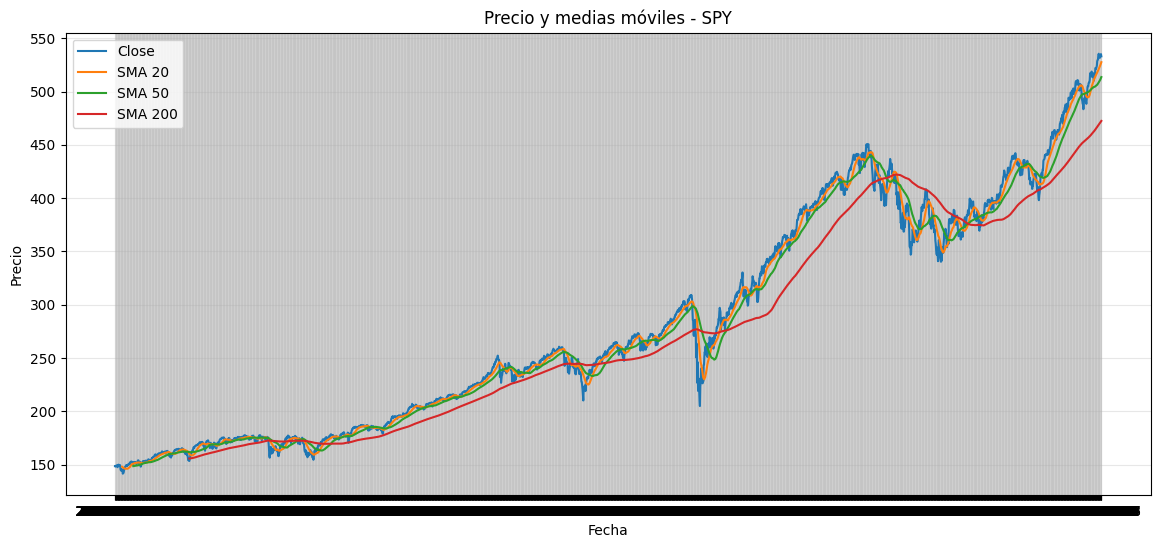

,Close_SPY,SMA_20_SPY,price_vs_sma_20_SPY
Date,,,
2014-01-30,145.582947,148.029949,-0.016530
2014-01-31,144.730103,147.837441,-0.021019
2014-02-03,141.472916,147.483291,-0.040753
2014-02-04,142.463867,147.200214,-0.032176
2014-02-05,142.285202,146.862716,-0.031169


,Close_SPY,SMA_20_SPY,SMA_50_SPY,trend_signal_sma20_50_SPY
Date,,,,
2014-03-14,149.993607,150.888733,148.600245,1
2014-03-17,151.350098,150.982549,148.655641,1
2014-03-18,152.430389,151.121445,148.733131,1
2014-03-19,151.618210,151.269282,148.802987,1
2014-03-20,152.503525,151.417522,148.872354,1


In [11]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

for window in [10, 20, 50, 100, 200]:
    sma = ohlcv_wide[close_cols].rolling(window).mean()
    sma.columns = [f"SMA_{window}_{ticker}" for ticker in tickers]

    ohlcv_wide = pd.concat([ohlcv_wide, sma], axis=1)

display(ohlcv_wide.head(250))

ticker_example = "SPY"

plt.figure(figsize=(14, 6))

plt.plot(ohlcv_wide.index, ohlcv_wide[f"Close_{ticker_example}"], label="Close")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_20_{ticker_example}"], label="SMA 20")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_50_{ticker_example}"], label="SMA 50")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_200_{ticker_example}"], label="SMA 200")

plt.title(f"Precio y medias móviles - {ticker_example}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for window in [10, 20, 50, 100, 200]:
    for ticker in tickers:
        ohlcv_wide[f"price_vs_sma_{window}_{ticker}"] = (
            ohlcv_wide[f"Close_{ticker}"] / ohlcv_wide[f"SMA_{window}_{ticker}"] - 1
        )

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"SMA_20_{ticker_example}",
            f"price_vs_sma_20_{ticker_example}",
        ]
    ].dropna().head()
)

for ticker in tickers:
    ohlcv_wide[f"trend_signal_sma20_50_{ticker}"] = np.where(
        ohlcv_wide[f"SMA_20_{ticker}"] > ohlcv_wide[f"SMA_50_{ticker}"],
        1,
        0
    )

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"SMA_20_{ticker_example}",
            f"SMA_50_{ticker_example}",
            f"trend_signal_sma20_50_{ticker_example}",
        ]
    ].dropna().head()
)

## Volatilidad

La volatilidad mide la intensidad con la que cambia el precio de un activo en el tiempo. En términos simples, no indica si un activo sube o baja, sino cuánto se mueve. Un activo con baja volatilidad suele tener variaciones diarias más pequeñas y estables, mientras que un activo con alta volatilidad puede experimentar subidas y caídas fuertes en periodos cortos. Por eso, la volatilidad se interpreta como una medida de riesgo: cuanto más alta es, mayor incertidumbre existe sobre el comportamiento futuro del precio. En análisis financiero se calcula normalmente como la desviación típica de los retornos durante una ventana móvil, por ejemplo 10, 20 o 50 días. Después puede anualizarse multiplicando por la raíz de 252, que representa aproximadamente el número de sesiones bursátiles en un año. Así se puede comparar la volatilidad reciente de distintos activos en una escala anual equivalente.

,volatility_10d_SPY,volatility_20d_SPY,volatility_50d_SPY
Date,,,
2014-03-17,0.006979,0.005765,0.007727
2014-03-18,0.005748,0.005946,0.007785
2014-03-19,0.005979,0.005866,0.007814
2014-03-20,0.006266,0.005863,0.007810
2014-03-21,0.006364,0.005947,0.007834


,volatility_20d_SPY,volatility_20d_annualized_SPY
Date,,
2014-01-31,0.007933,0.125928
2014-02-03,0.009233,0.146576
2014-02-04,0.009468,0.150296
2014-02-05,0.009280,0.147308
2014-02-06,0.009895,0.157086


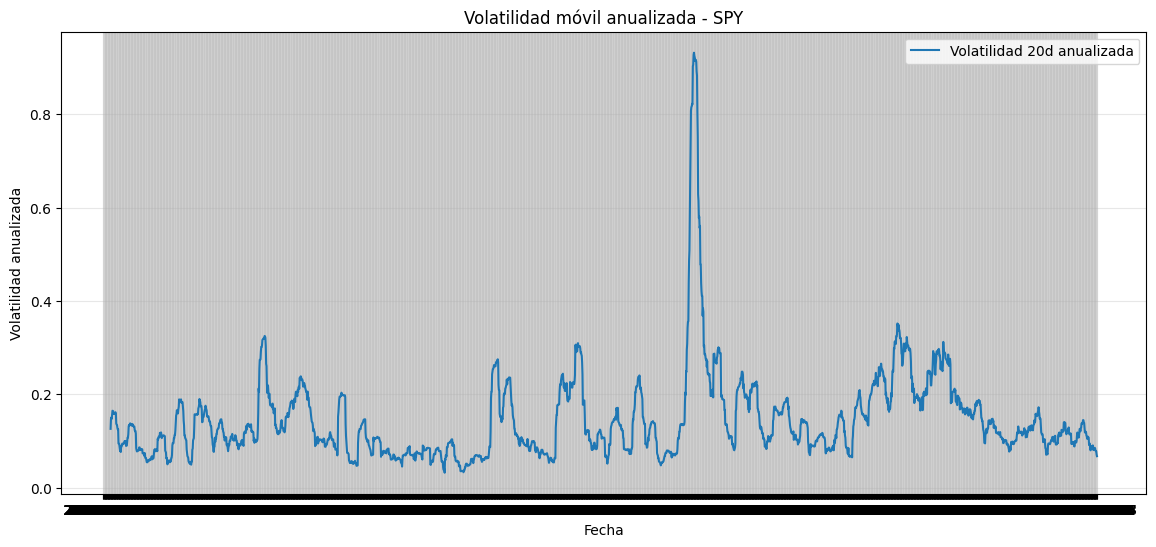

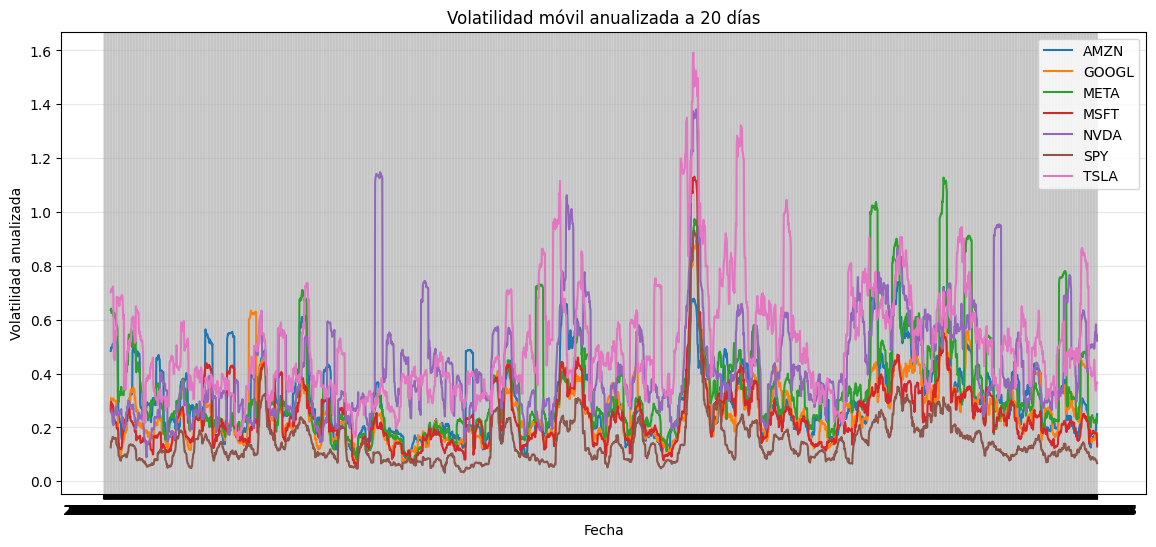

In [13]:
for window in [10, 20, 50]:
    for ticker in tickers:
        ohlcv_wide[f"volatility_{window}d_{ticker}"] = (
            returns_wide[ticker].rolling(window).std()
        )

display(
    ohlcv_wide[
        [
            f"volatility_10d_SPY",
            f"volatility_20d_SPY",
            f"volatility_50d_SPY",
        ]
    ].dropna().head()
)

for window in [10, 20, 50]:
    for ticker in tickers:
        ohlcv_wide[f"volatility_{window}d_annualized_{ticker}"] = (
            ohlcv_wide[f"volatility_{window}d_{ticker}"] * np.sqrt(252)
        )

display(
    ohlcv_wide[
        [
            f"volatility_20d_SPY",
            f"volatility_20d_annualized_SPY",
        ]
    ].dropna().head()
)

ticker_example = "SPY"

plt.figure(figsize=(14, 6))

plt.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"volatility_20d_annualized_{ticker_example}"],
    label="Volatilidad 20d anualizada"
)

plt.title(f"Volatilidad móvil anualizada - {ticker_example}")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad anualizada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(
        ohlcv_wide.index,
        ohlcv_wide[f"volatility_20d_annualized_{ticker}"],
        label=ticker
    )

plt.title("Volatilidad móvil anualizada a 20 días")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad anualizada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En los gráficos se observa que la volatilidad no es constante, sino que cambia por periodos. Esto es importante porque los activos financieros atraviesan fases tranquilas y fases de estrés. En el caso de SPY, la volatilidad móvil anualizada suele mantenerse en niveles relativamente moderados, pero presenta picos claros en momentos de crisis o alta incertidumbre de mercado. En la tabla, por ejemplo, una volatility_20d_SPY de 0.009895 significa que la desviación típica diaria de los retornos en los últimos 20 días fue aproximadamente del 0.99%. Al anualizarla, aparece como 0.157086, es decir, una volatilidad anualizada aproximada del 15.7%. En el gráfico comparativo, activos como TSLA, NVDA o META muestran picos de volatilidad más altos que SPY, lo cual es esperable porque son acciones individuales y tienen más riesgo específico. SPY, al representar un índice diversificado, suele ser más estable. Para el futuro modelo de trading, estas variables son útiles porque permiten que el algoritmo distinga entre entornos de mercado tranquilos y entornos de alta incertidumbre.

## Drawdown

El drawdown mide la caída de un activo desde su máximo histórico anterior hasta un punto posterior. A diferencia de la volatilidad, que mide cuánto fluctúan los retornos, el drawdown responde a una pregunta más práctica para un inversor: “¿cuánto habría llegado a perder desde el último máximo si hubiera mantenido la inversión?”. Por ejemplo, si una acción alcanza un valor de 100 y después cae a 70, su drawdown es del -30%. Cuando el precio vuelve a marcar un nuevo máximo, el drawdown vuelve a 0. Por eso, en los gráficos de drawdown la serie normalmente se mueve entre 0 y valores negativos: 0 significa que el activo está en máximos, mientras que valores negativos indican cuánto ha caído respecto a su máximo anterior.

,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Date,,,,,,,
2014-01-02,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2014-01-03,-0.003845,-0.007295,-0.002742,-0.006728,-0.01198,-0.000164,-0.003598
2014-01-06,-0.010905,0.000000,0.000000,-0.027718,0.00000,-0.003061,-0.020653
2014-01-07,0.000000,0.000000,0.000000,-0.020183,0.00000,0.000000,-0.004930
2014-01-08,0.000000,0.000000,0.000000,-0.037675,0.00000,0.000000,0.000000


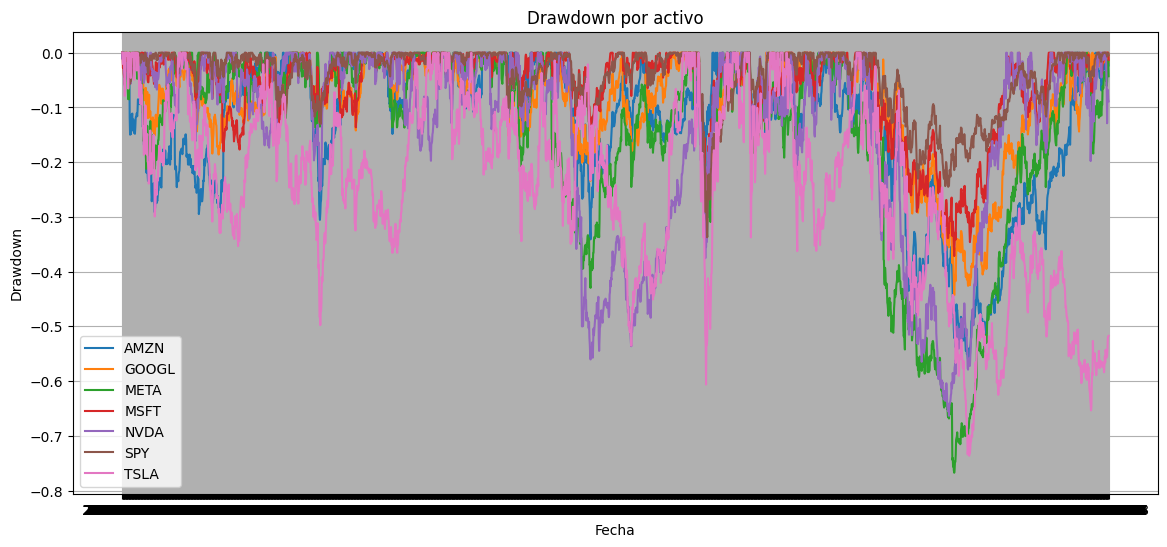

,max_drawdown,max_drawdown_%
META,-0.767361,-76.736091
TSLA,-0.736322,-73.632217
NVDA,-0.663351,-66.335091
AMZN,-0.561453,-56.145263
GOOGL,-0.443201,-44.320056
MSFT,-0.371485,-37.148481
SPY,-0.337173,-33.717273


In [15]:
def calculate_drawdown(price_series):
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    return drawdown

drawdown_wide = close_wide.apply(calculate_drawdown)

display(drawdown_wide.head())

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(drawdown_wide.index, drawdown_wide[ticker], label=ticker)

plt.title("Drawdown por activo")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

max_drawdown = drawdown_wide.min()

max_drawdown_df = pd.DataFrame({
    "max_drawdown": max_drawdown,
    "max_drawdown_%": max_drawdown * 100
}).sort_values("max_drawdown_%")

display(max_drawdown_df)

En el gráfico se observa que los distintos activos han sufrido caídas muy diferentes a lo largo del periodo analizado. SPY presenta drawdowns más moderados que varias acciones individuales, lo cual tiene sentido porque representa un índice diversificado y no depende de una sola empresa. En cambio, activos como META, TSLA o NVDA muestran caídas mucho más profundas en ciertos periodos, llegando a drawdowns superiores al 50% o incluso cercanos al 70% en algunos casos. En la tabla inicial, por ejemplo, un valor de -0.003845 para AMZN indica que ese día el precio estaba un 0.38% por debajo de su máximo acumulado hasta ese momento. Esta métrica es especialmente importante para evaluar estrategias de trading, porque una estrategia puede tener alta rentabilidad final pero ser poco atractiva si durante el camino sufre caídas demasiado grandes.

## Rentabilidad-riesgo

Arriba es mejor rentabilidad.
A la izquierda es menor riesgo.
Arriba-izquierda es ideal.

In [16]:
trading_days = 252

annual_metrics = pd.DataFrame(index=tickers)

annual_metrics["mean_daily_return"] = returns_wide.mean()
annual_metrics["daily_volatility"] = returns_wide.std()

annual_metrics["annual_return"] = annual_metrics["mean_daily_return"] * trading_days
annual_metrics["annual_volatility"] = annual_metrics["daily_volatility"] * np.sqrt(trading_days)

annual_metrics["sharpe_simple"] = (
    annual_metrics["annual_return"] / annual_metrics["annual_volatility"]
)

annual_metrics["annual_return_%"] = annual_metrics["annual_return"] * 100
annual_metrics["annual_volatility_%"] = annual_metrics["annual_volatility"] * 100

display(annual_metrics.sort_values("sharpe_simple", ascending=False))

,mean_daily_return,daily_volatility,annual_return,annual_volatility,sharpe_simple,annual_return_%,annual_volatility_%
NVDA,0.002628,0.029417,0.662212,0.466978,1.418080,66.221178,46.697760
MSFT,0.001151,0.016847,0.290116,0.267431,1.084828,29.011637,26.743086
AMZN,0.001075,0.020683,0.270902,0.328327,0.825098,27.090216,32.832706
SPY,0.000544,0.010876,0.136975,0.172655,0.793346,13.697485,17.265462
TSLA,0.001741,0.034983,0.438796,0.555339,0.790141,43.879572,55.533872
GOOGL,0.000866,0.017576,0.218301,0.279008,0.782420,21.830136,27.900804
META,0.001126,0.023709,0.283868,0.376362,0.754242,28.386755,37.636150


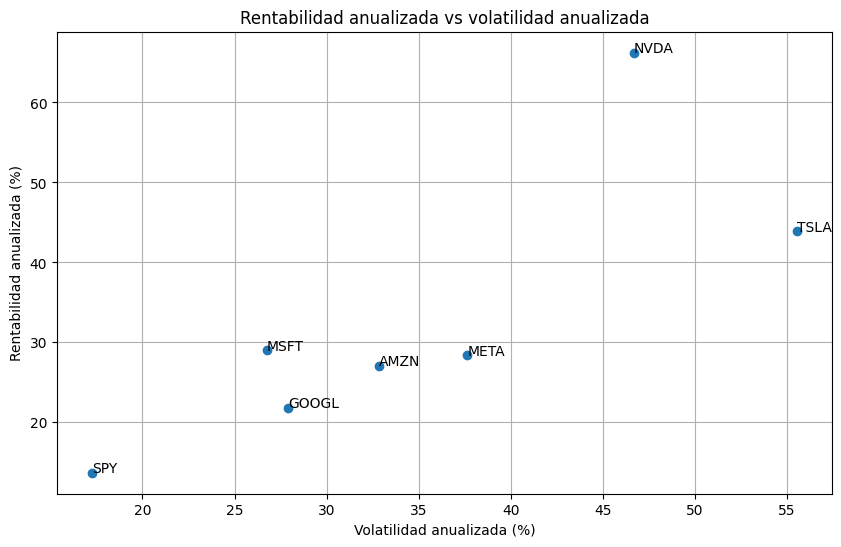

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    annual_metrics["annual_volatility_%"],
    annual_metrics["annual_return_%"]
)

for ticker in annual_metrics.index:
    plt.text(
        annual_metrics.loc[ticker, "annual_volatility_%"],
        annual_metrics.loc[ticker, "annual_return_%"],
        ticker
    )

plt.title("Rentabilidad anualizada vs volatilidad anualizada")
plt.xlabel("Volatilidad anualizada (%)")
plt.ylabel("Rentabilidad anualizada (%)")
plt.show()

## Correlaciones

La correlación mide si dos activos se mueven juntos.
Intuición:
- Si dos activos suben y bajan a la vez, tienen correlación alta.
- Si se mueven de forma independiente, correlación baja.

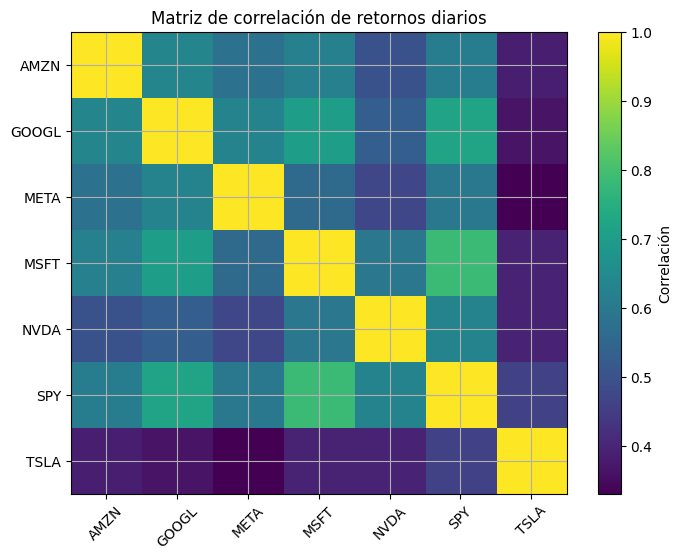

In [19]:
corr_matrix = returns_wide.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Matriz de correlación de retornos diarios")
plt.show()

SPY representa el mercado. Una acción muy correlacionada con SPY se mueve bastante con el mercado.
Una menos correlacionada tiene más comportamiento propio. La matriz muestra que la mayoría de activos tecnológicos tienen correlaciones positivas entre sí, lo que significa que sus retornos diarios tienden a moverse en la misma dirección con cierta frecuencia. Esto es esperable, porque AMZN, GOOGL, META, MSFT y NVDA pertenecen al sector tecnológico o están muy expuestas al mismo entorno macroeconómico: tipos de interés, expectativas de crecimiento, resultados empresariales y sentimiento del mercado. También se observa que SPY tiene una correlación relativamente alta con muchas de ellas, especialmente con MSFT y GOOGL, porque estas empresas tienen mucho peso dentro del índice S&P 500.

Sin embargo, no todos los activos se comportan igual. TSLA parece tener correlaciones más bajas con el resto, lo que indica un comportamiento más idiosincrático, es decir, más dependiente de factores propios de la empresa. NVDA también muestra correlaciones positivas, pero no necesariamente tan altas con todos los activos, reflejando que aunque forma parte del entorno tecnológico, su dinámica reciente puede estar más marcada por factores específicos como semiconductores e inteligencia artificial. En términos de cartera, esta matriz sirve para entender diversificación: si todos los activos están muy correlacionados, combinarlos reduce menos el riesgo; si algunos tienen menor correlación, pueden aportar algo más de diversificación.

## Beta frente al mercado

Calcular beta frente a SPY. En este contexto, beta mide cuánto se mueve cada activo en relación con el mercado, usando SPY como referencia. Una beta de 1 significa que el activo se mueve aproximadamente como el mercado; una beta superior a 1 indica que el activo tiende a amplificar los movimientos del mercado. Por ejemplo, NVDA tiene una beta aproximada de 1.71, lo que sugiere que, históricamente, ha sido bastante más sensible que SPY: cuando el mercado sube, NVDA tiende a subir más, pero cuando el mercado cae, también puede caer más. TSLA, META, MSFT, GOOGL y AMZN también tienen beta superior a 1, por lo que en este periodo se comportan como activos más agresivos que el índice.

In [21]:
market = "SPY"

betas = {}

for ticker in tickers:
    temp = pd.DataFrame({
        "asset": returns_wide[ticker],
        "market": returns_wide[market]
    }).dropna()
    
    covariance = temp["asset"].cov(temp["market"])
    market_variance = temp["market"].var()
    
    beta = covariance / market_variance
    betas[ticker] = beta

beta_df = pd.DataFrame.from_dict(betas, orient="index", columns=["beta_vs_SPY"])
beta_df = beta_df.sort_values("beta_vs_SPY", ascending=False)

display(beta_df)

,beta_vs_SPY
NVDA,1.705993
TSLA,1.482061
META,1.305486
MSFT,1.220336
GOOGL,1.166111
AMZN,1.166022
SPY,1.000000


Alfa simple frente a SPY. Alfa, en cambio, intenta medir la rentabilidad adicional que obtiene un activo después de tener en cuenta su exposición al mercado. Es decir, no pregunta solo “¿ha subido mucho?”, sino “¿ha subido más de lo que cabría esperar dado su nivel de riesgo frente a SPY?”. En tu tabla, NVDA tiene un alfa anualizado positivo muy alto, alrededor del 42.85%, lo que indica que, durante el periodo analizado, generó una rentabilidad muy superior a la explicada únicamente por su beta frente al mercado. TSLA, MSFT, AMZN, META y GOOGL también muestran alfa positivo. SPY aparece con alfa prácticamente cero porque es el propio benchmark utilizado como mercado de referencia.

In [22]:
alpha_df = pd.DataFrame(index=tickers)

for ticker in tickers:
    temp = pd.DataFrame({
        "asset": returns_wide[ticker],
        "market": returns_wide[market]
    }).dropna()
    
    beta = beta_df.loc[ticker, "beta_vs_SPY"]
    
    daily_alpha = temp["asset"].mean() - beta * temp["market"].mean()
    annual_alpha = daily_alpha * 252
    
    alpha_df.loc[ticker, "annual_alpha"] = annual_alpha
    alpha_df.loc[ticker, "annual_alpha_%"] = annual_alpha * 100

display(alpha_df.sort_values("annual_alpha_%", ascending=False))

,annual_alpha,annual_alpha_%
NVDA,4.285337e-01,4.285337e+01
TSLA,2.357906e-01,2.357906e+01
MSFT,1.229610e-01,1.229610e+01
AMZN,1.111864e-01,1.111864e+01
META,1.050488e-01,1.050488e+01
GOOGL,5.857349e-02,5.857349e+00
SPY,-5.464379e-17,-5.464379e-15


## Volumen

El volumen representa cuántas acciones, participaciones o contratos se han negociado durante un periodo, normalmente un día. Si el precio nos dice “a cuánto se está comprando o vendiendo”, el volumen nos dice “cuánta actividad real hay detrás de ese movimiento”. Por eso, el volumen no indica directamente si un activo va a subir o bajar, pero sí ayuda a interpretar la fuerza del movimiento. Una subida con poco volumen puede ser menos convincente, porque participa poca gente; una subida con volumen alto puede interpretarse como un movimiento con más apoyo del mercado. Lo mismo ocurre con las caídas: una caída con volumen alto puede indicar presión vendedora fuerte.

Una forma útil de analizarlo es comparar el volumen actual con su media reciente. Para eso usamos una media móvil de volumen, por ejemplo volume_sma_20, que calcula el volumen medio de los últimos 20 días. Después podemos crear una variable como volume_vs_sma_20, que mide cuánto se aleja el volumen actual de su volumen normal reciente. Si esta variable es positiva, el día tuvo más volumen de lo habitual; si es negativa, tuvo menos. Esto es útil para modelos de trading porque permite detectar sesiones “anómalas”, donde el mercado está negociando mucho más o mucho menos de lo normal.

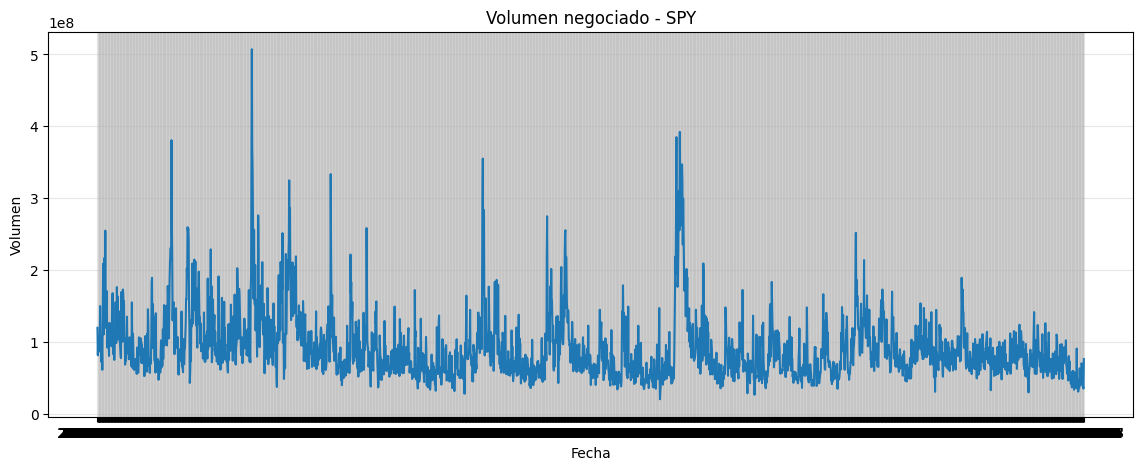

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\559812837.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"volume_sma_{window}_{ticker}"] = (
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\559812837.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"volume_sma_{window}_{ticker}"] = (
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\559812837.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

,Volume_SPY,volume_sma_20_SPY,volume_vs_sma_20_SPY
Date,,,
2014-01-30,118938100,116798650.0,0.018317
2014-01-31,194677900,120550700.0,0.614905
2014-02-03,254837100,129223025.0,0.972072
2014-02-04,165012400,132072235.0,0.249410
2014-02-05,164230500,135976550.0,0.207785


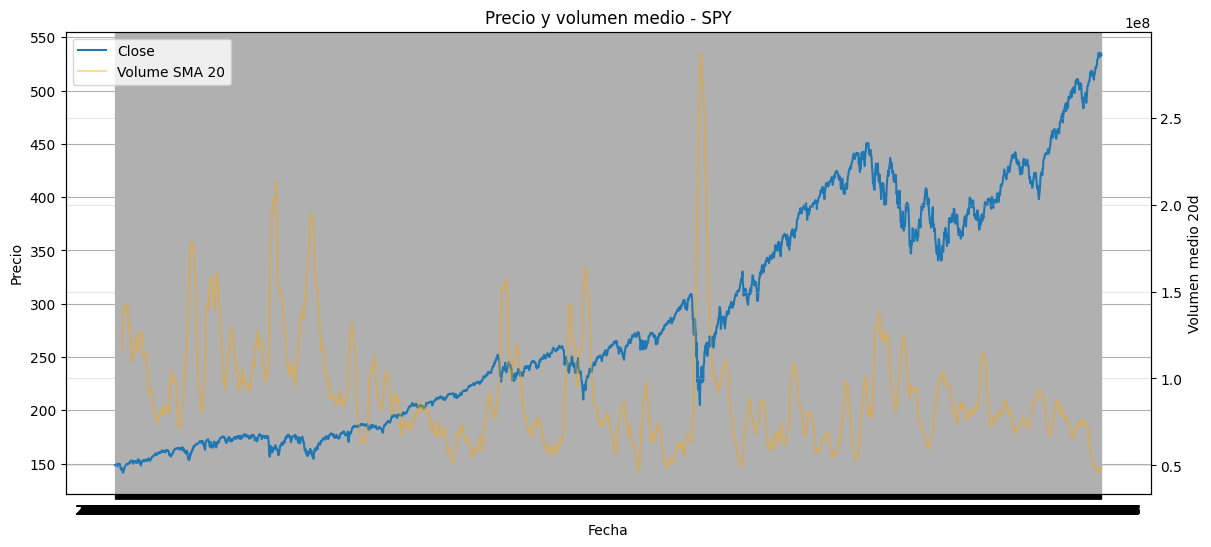

In [24]:
ticker_example = "SPY"

plt.figure(figsize=(14, 5))
plt.plot(ohlcv_wide.index, ohlcv_wide[f"Volume_{ticker_example}"])

plt.title(f"Volumen negociado - {ticker_example}")
plt.xlabel("Fecha")
plt.ylabel("Volumen")
plt.grid(True, alpha=0.3)
plt.show()
for window in [10, 20, 50]:
    for ticker in tickers:
        ohlcv_wide[f"volume_sma_{window}_{ticker}"] = (
            ohlcv_wide[f"Volume_{ticker}"].rolling(window).mean()
        )

for ticker in tickers:
    ohlcv_wide[f"volume_vs_sma_20_{ticker}"] = (
        ohlcv_wide[f"Volume_{ticker}"] / ohlcv_wide[f"volume_sma_20_{ticker}"] - 1
    )

display(
    ohlcv_wide[
        [
            f"Volume_{ticker_example}",
            f"volume_sma_20_{ticker_example}",
            f"volume_vs_sma_20_{ticker_example}",
        ]
    ].dropna().head()
)
ticker_example = "SPY"

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"Close_{ticker_example}"],
    label="Close"
)
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Precio")

ax2 = ax1.twinx()
ax2.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"volume_sma_20_{ticker_example}"],
    label="Volume SMA 20",
    alpha=0.4,
    color="orange"
)
ax2.set_ylabel("Volumen medio 20d")

plt.title(f"Precio y volumen medio - {ticker_example}")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.grid(True, alpha=0.3)
plt.show()

En el caso de SPY, el precio de cierre muestra una tendencia creciente de largo plazo, mientras que el volumen no sigue una tendencia ascendente tan clara. El volumen aparece más concentrado en picos concretos, lo que suele asociarse a sesiones de mayor incertidumbre, movimientos bruscos o eventos relevantes de mercado. Esto indica que los momentos de mayor negociación no tienen por qué coincidir con los precios más altos, sino con situaciones en las que aumenta la actividad de compradores y vendedores.

En la tabla, Volume_SPY indica el volumen negociado en cada sesión, volume_sma_20_SPY representa el volumen medio de los últimos 20 días y volume_vs_sma_20_SPY mide la diferencia relativa entre ambos. Por ejemplo, un valor de 0.614905 significa que el volumen diario fue aproximadamente un 61.49% superior a su media reciente. Un valor de 0.972072 indica que el volumen fue casi un 97.21% superior, prácticamente el doble de lo habitual. Para un modelo de Machine Learning, esta variable puede aportar información adicional porque distingue entre movimientos de precio con actividad normal y movimientos acompañados de una participación de mercado excepcionalmente alta.

## RSI

El RSI, o Relative Strength Index, es un indicador técnico que intenta medir la fuerza reciente del movimiento de un activo. No trabaja directamente con el precio absoluto, sino con la relación entre subidas y bajadas recientes. Normalmente se calcula con una ventana de 14 días, por eso aparece como RSI 14. Su valor siempre está entre 0 y 100. De forma general, un RSI alto indica que el activo ha tenido muchas subidas recientes frente a bajadas; un RSI bajo indica que ha tenido más presión bajista reciente.

La interpretación clásica usa dos niveles de referencia: 70 y 30. Si el RSI está por encima de 70, se suele decir que el activo está en zona de sobrecompra, es decir, ha subido mucho en poco tiempo y podría estar extendido. Si el RSI está por debajo de 30, se suele decir que está en zona de sobreventa, es decir, ha caído bastante recientemente y podría estar debilitado o cerca de un rebote. Pero esto no debe interpretarse como una regla automática. Un RSI alto no significa que el precio vaya a caer seguro, y un RSI bajo no significa que vaya a subir seguro. En tendencias fuertes, el RSI puede permanecer mucho tiempo en niveles altos o bajos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\3886178518.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"rsi_14_{ticker}"] = calculate_rsi(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\3886178518.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"rsi_14_{ticker}"] = calculate_rsi(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\3886178518.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

,rsi_14_AMZN,rsi_14_GOOGL,rsi_14_META,rsi_14_MSFT,rsi_14_NVDA,rsi_14_SPY,rsi_14_TSLA
Date,,,,,,,
2014-01-23,51.888651,69.175540,56.425670,41.863833,51.971461,49.406592,74.763407
2014-01-24,42.758838,56.249637,49.675913,49.311350,48.172722,36.504715,67.947251
2014-01-27,43.828720,45.000955,38.017041,49.311240,42.758562,35.662604,65.669154
2014-01-28,47.156398,45.082827,41.366483,49.030524,40.501879,35.406887,68.465261
2014-01-29,37.277426,40.190975,36.494275,56.465615,33.455831,31.625915,65.004387


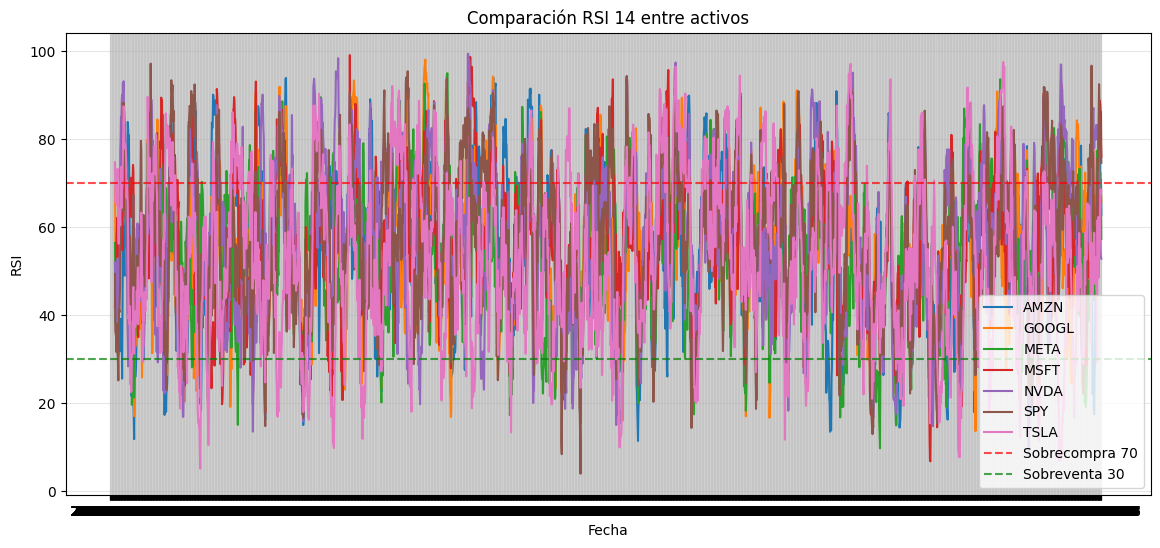

In [26]:
def calculate_rsi(price_series, window=14):
    delta = price_series.diff()
    
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    
    avg_gain = gains.rolling(window).mean()
    avg_loss = losses.rolling(window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi


for ticker in tickers:
    ohlcv_wide[f"rsi_14_{ticker}"] = calculate_rsi(
        ohlcv_wide[f"Close_{ticker}"],
        window=14
    )

rsi_cols = [f"rsi_14_{ticker}" for ticker in tickers]

display(
    ohlcv_wide[rsi_cols].dropna().head()
)


plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(
        ohlcv_wide.index,
        ohlcv_wide[f"rsi_14_{ticker}"],
        label=ticker
    )

plt.axhline(70, linestyle="--", color="red", alpha=0.7, label="Sobrecompra 70")
plt.axhline(30, linestyle="--", color="green", alpha=0.7, label="Sobreventa 30")

plt.title("Comparación RSI 14 entre activos")
plt.xlabel("Fecha")
plt.ylabel("RSI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

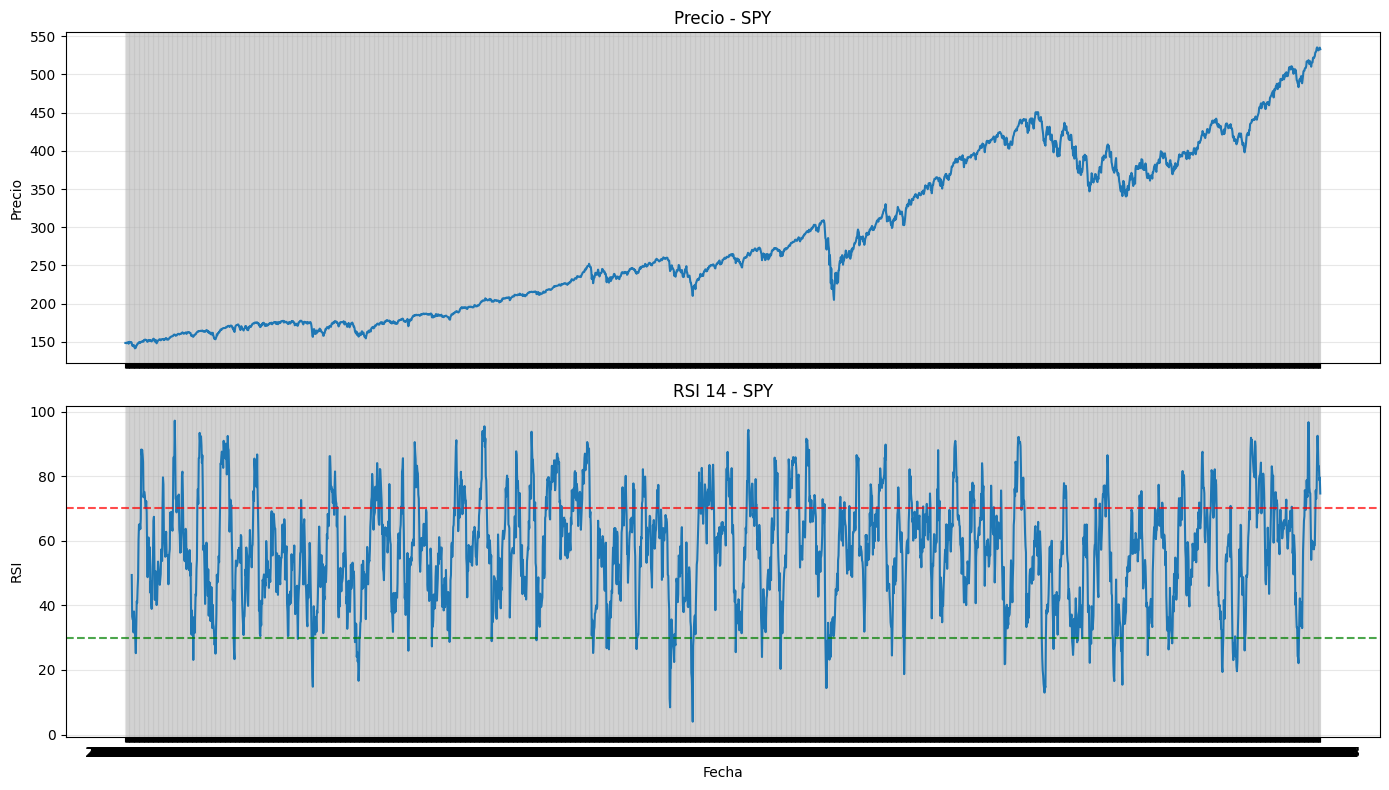

In [27]:
ticker_example = "SPY"

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(
    ohlcv_wide.index,
    ohlcv_wide[f"Close_{ticker_example}"],
    label="Close"
)
ax[0].set_title(f"Precio - {ticker_example}")
ax[0].set_ylabel("Precio")
ax[0].grid(True, alpha=0.3)

ax[1].plot(
    ohlcv_wide.index,
    ohlcv_wide[f"rsi_14_{ticker_example}"],
    label="RSI 14"
)
ax[1].axhline(70, linestyle="--", color="red", alpha=0.7)
ax[1].axhline(30, linestyle="--", color="green", alpha=0.7)
ax[1].set_title(f"RSI 14 - {ticker_example}")
ax[1].set_ylabel("RSI")
ax[1].set_xlabel("Fecha")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En el caso de SPY, el gráfico superior muestra la evolución del precio y el gráfico inferior muestra el RSI de 14 días. Las líneas horizontales marcan las zonas típicas de referencia: alrededor de 70 para sobrecompra y alrededor de 30 para sobreventa. Cuando el RSI se aproxima o supera 70, significa que SPY ha tenido una fase reciente de fuerza compradora. Cuando se acerca o cae por debajo de 30, indica una fase reciente de debilidad o presión vendedora. Por ejemplo, en la tabla se ve que rsi_14_SPY pasa de valores cercanos a 49 a valores alrededor de 31 en pocos días, lo que refleja una pérdida clara de momentum en ese tramo.

Para un modelo de Machine Learning, el RSI es útil porque convierte una idea técnica, la fuerza relativa reciente del precio, en una variable numérica. Un modelo puede aprender si ciertos rangos de RSI están asociados con mayor probabilidad de subida, caída o reversión en los próximos días. Aun así, el RSI no debería usarse de forma aislada. Es más informativo cuando se combina con otras variables como retornos recientes, medias móviles, volatilidad, volumen y distancia del precio a sus medias. Así el modelo no solo ve si el activo está “fuerte” o “débil”, sino también en qué contexto de tendencia y riesgo ocurre esa señal.

## Bandas de Bollinger

Las Bandas de Bollinger son un indicador técnico que sirve para analizar si el precio está relativamente alto, bajo o en una zona normal respecto a su comportamiento reciente. Se construyen a partir de tres líneas: una media móvil central, normalmente de 20 días, una banda superior y una banda inferior. La banda superior se calcula sumando dos desviaciones típicas a la media móvil, y la banda inferior se calcula restando dos desviaciones típicas. Por tanto, las bandas combinan dos ideas: tendencia, mediante la media móvil, y volatilidad, mediante la anchura de las bandas.

La interpretación básica es que cuando el precio está cerca de la banda superior, el activo está cotizando en la parte alta de su rango reciente; cuando está cerca de la banda inferior, está en la parte baja. Esto no significa automáticamente que vaya a caer o subir. En una tendencia fuerte, el precio puede mantenerse cerca de la banda superior durante bastante tiempo. En cambio, en mercados laterales, tocar la banda superior puede sugerir sobreextensión y tocar la inferior puede sugerir posible rebote. Por eso las Bandas de Bollinger no deben usarse como señal aislada, sino junto con tendencia, volumen, volatilidad y otros indicadores.

In [28]:
window = 20

for ticker in tickers:
    close_col = f"Close_{ticker}"

    ohlcv_wide[f"bb_middle_20_{ticker}"] = (
        ohlcv_wide[close_col].rolling(window).mean()
    )

    ohlcv_wide[f"bb_std_20_{ticker}"] = (
        ohlcv_wide[close_col].rolling(window).std()
    )

    ohlcv_wide[f"bb_upper_20_{ticker}"] = (
        ohlcv_wide[f"bb_middle_20_{ticker}"] + 2 * ohlcv_wide[f"bb_std_20_{ticker}"]
    )

    ohlcv_wide[f"bb_lower_20_{ticker}"] = (
        ohlcv_wide[f"bb_middle_20_{ticker}"] - 2 * ohlcv_wide[f"bb_std_20_{ticker}"]
    )

    ohlcv_wide[f"bb_position_20_{ticker}"] = (
        (ohlcv_wide[close_col] - ohlcv_wide[f"bb_lower_20_{ticker}"]) /
        (ohlcv_wide[f"bb_upper_20_{ticker}"] - ohlcv_wide[f"bb_lower_20_{ticker}"])
    )

ticker_example = "SPY"

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"bb_lower_20_{ticker_example}",
            f"bb_middle_20_{ticker_example}",
            f"bb_upper_20_{ticker_example}",
            f"bb_position_20_{ticker_example}",
        ]
    ].dropna().head()
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\1406875283.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"bb_middle_20_{ticker}"] = (
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\1406875283.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ohlcv_wide[f"bb_std_20_{ticker}"] = (
C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\1406875283.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

,Close_SPY,bb_lower_20_SPY,bb_middle_20_SPY,bb_upper_20_SPY,bb_position_20_SPY
Date,,,,,
2014-01-30,145.582947,144.210808,148.029949,151.849091,0.179640
2014-01-31,144.730103,143.755963,147.837441,151.918919,0.119337
2014-02-03,141.472916,142.528544,147.483291,152.438038,-0.106527
2014-02-04,142.463867,141.775322,147.200214,152.625105,0.063462
2014-02-05,142.285202,141.089783,146.862716,152.635649,0.103537


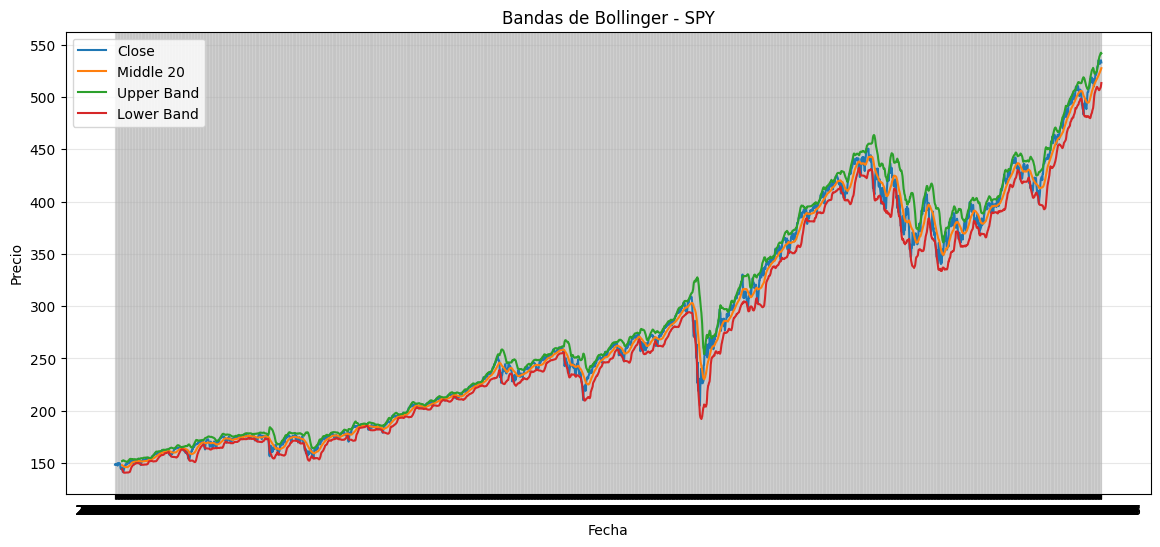

In [29]:
ticker_example = "SPY"

plt.figure(figsize=(14, 6))

plt.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"Close_{ticker_example}"],
    label="Close"
)

plt.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"bb_middle_20_{ticker_example}"],
    label="Middle 20"
)

plt.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"bb_upper_20_{ticker_example}"],
    label="Upper Band"
)

plt.plot(
    ohlcv_wide.index,
    ohlcv_wide[f"bb_lower_20_{ticker_example}"],
    label="Lower Band"
)

plt.title(f"Bandas de Bollinger - {ticker_example}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En el caso de SPY, la línea central representa la media móvil de 20 días, mientras que las bandas superior e inferior muestran el rango dinámico esperado según la volatilidad reciente. Cuando el precio se mueve dentro de las bandas, se encuentra dentro de un rango relativamente normal respecto a los últimos 20 días. Cuando se acerca mucho a la banda superior, indica fuerza reciente o posible sobreextensión; cuando se aproxima a la banda inferior, indica debilidad reciente o presión bajista. En periodos de alta volatilidad, las bandas se abren; en periodos tranquilos, se estrechan.

## MACD

El MACD significa Moving Average Convergence Divergence. Es un indicador técnico que intenta medir el momentum de un activo, es decir, si el movimiento reciente del precio está ganando o perdiendo fuerza. Se construye comparando dos medias móviles exponenciales: una rápida, normalmente de 12 periodos, y una lenta, normalmente de 26 periodos. Si la media rápida está por encima de la lenta, el MACD suele ser positivo y puede interpretarse como momentum alcista. Si la media rápida cae por debajo de la lenta, el MACD suele ser negativo y puede interpretarse como momentum bajista.

El MACD suele representarse con tres elementos: la línea MACD, la línea Signal y el histograma. La línea MACD mide la diferencia entre la media rápida y la lenta. La línea Signal es una media suavizada del propio MACD, normalmente de 9 periodos. El histograma mide la diferencia entre MACD y Signal. Cuando el histograma está por encima de cero, el MACD está por encima de la señal y puede indicar fuerza positiva; cuando está por debajo de cero, puede indicar pérdida de fuerza. Aun así, no debe entenderse como una señal automática de compra o venta, sino como una forma de cuantificar cambios de momentum.

funcion

In [31]:
def calculate_macd(price_series, fast=12, slow=26, signal=9):
    ema_fast = price_series.ewm(span=fast, adjust=False).mean()
    ema_slow = price_series.ewm(span=slow, adjust=False).mean()
    
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    
    return macd, macd_signal, macd_hist

,Close_SPY,macd_SPY,macd_signal_SPY,macd_hist_SPY
Date,,,,
2014-01-02,148.580261,0.000000,0.000000,0.000000
2014-01-03,148.555923,-0.001941,-0.000388,-0.001553
2014-01-06,148.125412,-0.037783,-0.007867,-0.029916
2014-01-07,149.035156,0.007138,-0.004866,0.012005
2014-01-08,149.067627,0.044842,0.005076,0.039767


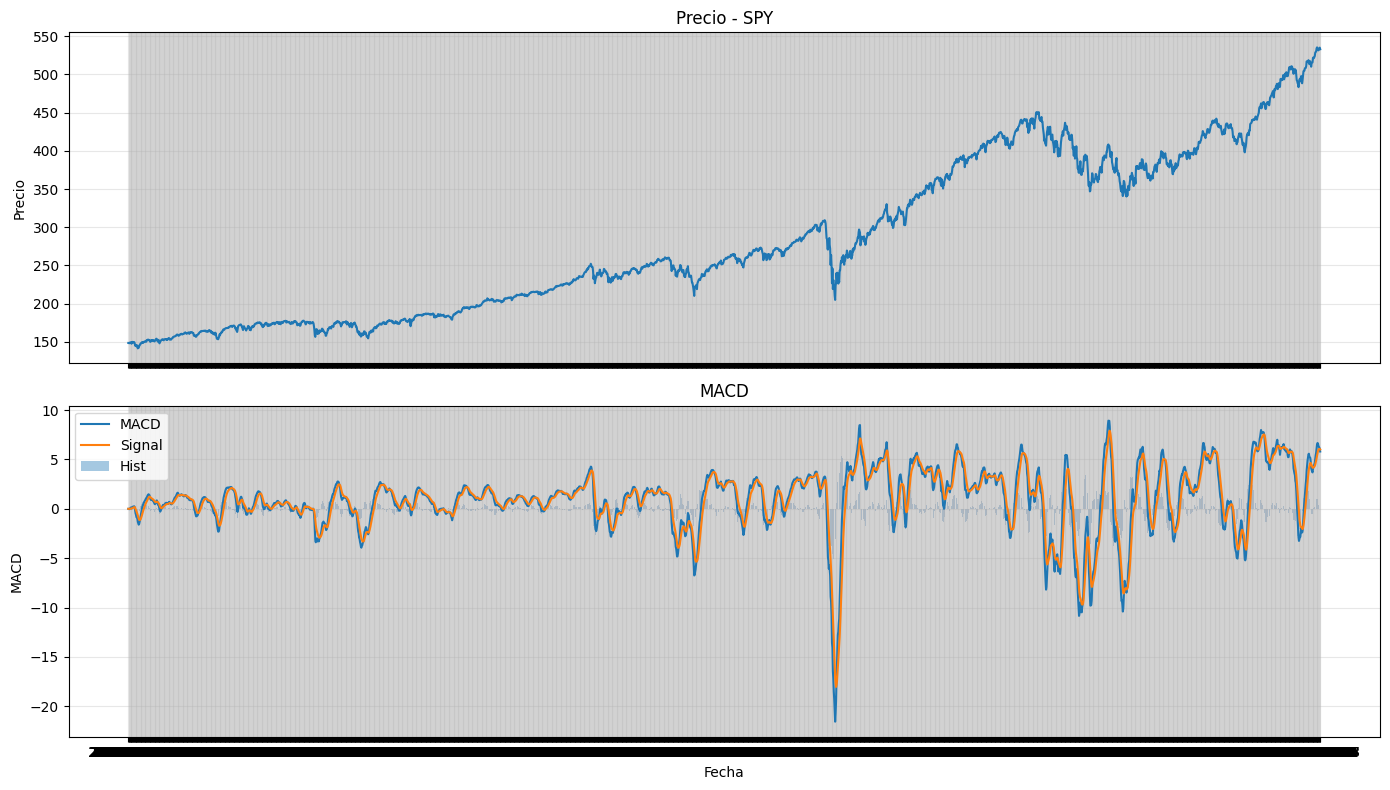

In [33]:
for ticker in tickers:
    macd, macd_signal, macd_hist = calculate_macd(
        ohlcv_wide[f"Close_{ticker}"]
    )
    
    ohlcv_wide[f"macd_{ticker}"] = macd
    ohlcv_wide[f"macd_signal_{ticker}"] = macd_signal
    ohlcv_wide[f"macd_hist_{ticker}"] = macd_hist

ticker_example = "SPY"

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"macd_{ticker_example}",
            f"macd_signal_{ticker_example}",
            f"macd_hist_{ticker_example}",
        ]
    ].dropna().head()
)

ticker_example = "SPY"

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(
    ohlcv_wide.index,
    ohlcv_wide[f"Close_{ticker_example}"]
)
ax[0].set_title(f"Precio - {ticker_example}")
ax[0].set_ylabel("Precio")
ax[0].grid(True, alpha=0.3)

ax[1].plot(
    ohlcv_wide.index,
    ohlcv_wide[f"macd_{ticker_example}"],
    label="MACD"
)
ax[1].plot(
    ohlcv_wide.index,
    ohlcv_wide[f"macd_signal_{ticker_example}"],
    label="Signal"
)
ax[1].bar(
    ohlcv_wide.index,
    ohlcv_wide[f"macd_hist_{ticker_example}"],
    label="Hist",
    alpha=0.4
)
ax[1].set_title("MACD")
ax[1].set_ylabel("MACD")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

En el caso de SPY, el gráfico superior muestra el precio y el inferior muestra el MACD. Se observa que el MACD oscila alrededor de cero: valores positivos suelen aparecer en fases donde el precio mantiene una tendencia alcista o gana fuerza, mientras que valores negativos aparecen en correcciones o fases de debilidad. En la tabla, por ejemplo, macd_SPY = -0.037783 indica que la media rápida estaba ligeramente por debajo de la media lenta, reflejando un momentum algo negativo. En cambio, macd_SPY = 0.044842 muestra que la media rápida ya estaba por encima de la lenta, indicando recuperación de momentum.

## Comparación por años

Rentabilidad anual por activo

In [35]:
returns_long = returns_wide.reset_index().melt(
    id_vars="Date",
    var_name="Ticker",
    value_name="return_1d"
)

returns_long["Date"] = pd.to_datetime(returns_long["Date"])
returns_long["Year"] = returns_long["Date"].dt.year

annual_returns_by_year = (
    returns_long
    .dropna()
    .groupby(["Year", "Ticker"])["return_1d"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

display(annual_returns_by_year.head())

,Year,Ticker,return_1d
0,2014,AMZN,-0.220167
1,2014,GOOGL,-0.047489
2,2014,META,0.426064
3,2014,MSFT,0.284228
4,2014,NVDA,0.286810


Tabla de rentabilidades anuales

In [36]:
annual_returns_table = annual_returns_by_year.pivot(
    index="Year",
    columns="Ticker",
    values="return_1d"
)

display(annual_returns_table)

Ticker,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Year,,,,,,,
2014,-0.220167,-0.047489,0.426064,0.284228,0.286810,0.145617,0.481745
2015,1.177831,0.466118,0.341451,0.226919,0.671156,0.012343,0.079133
2016,0.109456,0.018560,0.099274,0.150777,2.269604,0.119979,-0.109662
2017,0.559564,0.329296,0.533768,0.407306,0.819878,0.217054,0.457017
2018,0.284317,-0.008012,-0.257112,0.207953,-0.308152,-0.045690,0.068894
2019,0.230277,0.281762,0.565718,0.575581,0.769430,0.312238,0.257001
2020,0.762561,0.308536,0.330865,0.425341,1.222957,0.183316,7.434370
2021,0.023768,0.652958,0.231329,0.524769,1.254821,0.287288,0.497556
2022,-0.496152,-0.390896,-0.642218,-0.280248,-0.502647,-0.181754,-0.650315


Heatmap simple de rentabilidades anuales

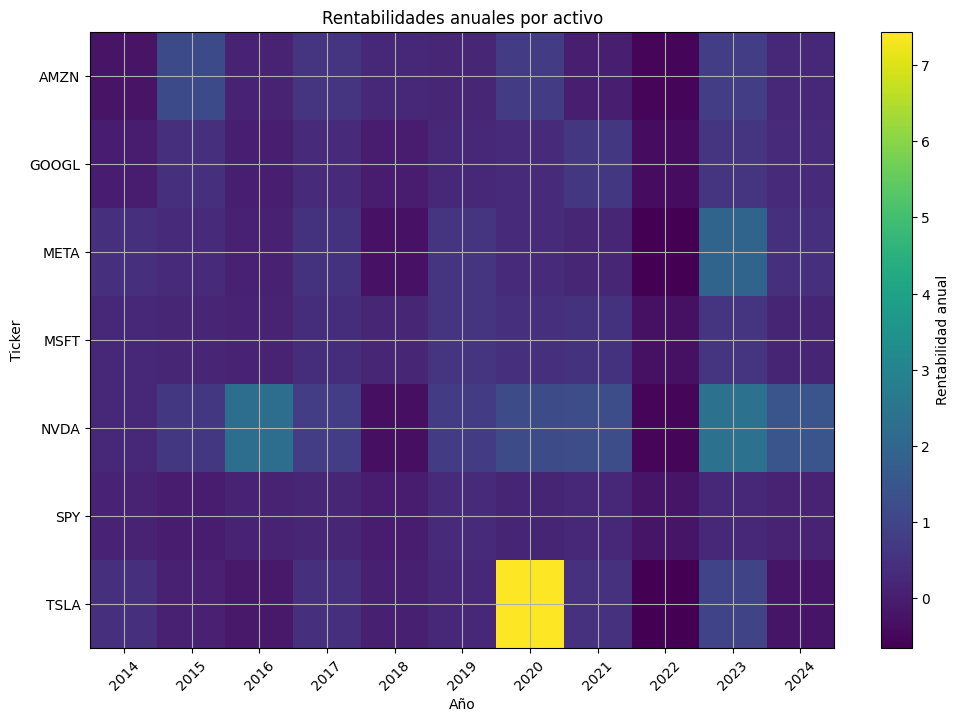

In [37]:
plt.figure(figsize=(12, 8))

plt.imshow(annual_returns_table.T, aspect="auto")
plt.colorbar(label="Rentabilidad anual")

plt.xticks(range(len(annual_returns_table.index)), annual_returns_table.index, rotation=45)
plt.yticks(range(len(annual_returns_table.columns)), annual_returns_table.columns)

plt.title("Rentabilidades anuales por activo")
plt.xlabel("Año")
plt.ylabel("Ticker")
plt.show()

Resumen financiero completo

In [40]:
corr_with_spy = returns_wide.corr()["SPY"]

financial_summary = pd.DataFrame(index=tickers)

financial_summary["start_date"] = summary_dates.set_index("Ticker")["min"]
financial_summary["end_date"] = summary_dates.set_index("Ticker")["max"]
financial_summary["n_observations"] = summary_dates.set_index("Ticker")["count"]

financial_summary["total_return_%"] = total_return * 100
financial_summary["annual_return_%"] = annual_metrics["annual_return_%"]
financial_summary["annual_volatility_%"] = annual_metrics["annual_volatility_%"]
financial_summary["sharpe_simple"] = annual_metrics["sharpe_simple"]
financial_summary["max_drawdown_%"] = max_drawdown * 100
financial_summary["corr_with_SPY"] = corr_with_spy
financial_summary["beta_vs_SPY"] = beta_df["beta_vs_SPY"]
financial_summary["annual_alpha_%"] = alpha_df["annual_alpha_%"]

financial_summary = financial_summary.sort_values("sharpe_simple", ascending=False)

display(financial_summary)

financial_summary.to_csv("datos/financial_eda_summary.csv")

ohlcv_wide.to_csv("datos/ohlcv_wide_with_financial_features.csv")

print("Archivos guardados:")
print("- datos/financial_eda_summary.csv")
print("- datos/ohlcv_wide_with_financial_features.csv")

,start_date,end_date,n_observations,total_return_%,annual_return_%,annual_volatility_%,sharpe_simple,max_drawdown_%,corr_with_SPY,beta_vs_SPY,annual_alpha_%
NVDA,2014-01-02,2024-06-28,2640,32929.974477,66.221178,46.697760,1.418080,-66.335091,0.630753,1.705993,4.285337e+01
MSFT,2014-01-02,2024-06-28,2640,1333.596790,29.011637,26.743086,1.084828,-37.148481,0.787855,1.220336,1.229610e+01
AMZN,2014-01-02,2024-06-28,2640,871.178710,27.090216,32.832706,0.825098,-56.145263,0.613166,1.166022,1.111864e+01
SPY,2014-01-02,2024-06-28,2640,258.731343,13.697485,17.265462,0.793346,-33.717273,1.000000,1.000000,-5.464379e-15
TSLA,2014-01-02,2024-06-28,2640,1877.481635,43.879572,55.533872,0.790141,-73.632217,0.460772,1.482061,2.357906e+01
GOOGL,2014-01-02,2024-06-28,2640,554.652406,21.830136,27.900804,0.782420,-44.320056,0.721608,1.166111,5.857349e+00
META,2014-01-02,2024-06-28,2640,823.516888,28.386755,37.636150,0.754242,-76.736091,0.598887,1.305486,1.050488e+01


Archivos guardados:
- datos/financial_eda_summary.csv
- datos/ohlcv_wide_with_financial_features.csv


En el periodo analizado, NVDA destaca claramente como el activo con mejor comportamiento, con una rentabilidad total extraordinariamente superior al resto y el mayor Sharpe simple, aunque también con una volatilidad elevada y un drawdown muy profundo. Esto indica que ha sido el activo más rentable en términos ajustados por riesgo, pero no necesariamente el más estable. TSLA también presenta una rentabilidad total muy alta, pero con la mayor volatilidad y uno de los peores drawdowns, por lo que su rendimiento ha venido acompañado de un riesgo extremo. MSFT aparece como uno de los activos más equilibrados: alta rentabilidad, volatilidad más moderada que NVDA, TSLA, META o AMZN, mejor Sharpe que SPY y un drawdown relativamente contenido. SPY, al ser el índice de referencia, muestra menor rentabilidad que las grandes tecnológicas, pero también menor volatilidad y menor drawdown, actuando como benchmark diversificado. En cuanto a exposición al mercado, todos los activos presentan beta superior a 1 frente a SPY, especialmente NVDA y TSLA, lo que confirma que son más sensibles que el mercado. Además, todos muestran alfa anualizado positivo frente a SPY, especialmente NVDA, lo que sugiere que durante este periodo generaron rentabilidad adicional no explicada únicamente por su exposición al índice.

## Preparación para ML

En esta parte se prepara el dataset final que utilizará el modelo de Machine Learning. El objetivo no es predecir el precio exacto de una acción, sino formular el problema como una tarea de clasificación binaria: para cada activo y fecha, se intentará predecir si el precio de cierre será mayor dentro de cinco sesiones bursátiles. Para ello, se construyen variables explicativas basadas únicamente en información disponible hasta el día actual, como retornos recientes, medias móviles, volatilidad, volumen, RSI, Bandas de Bollinger y MACD. Además, se preparan dos enfoques comparativos: un primer enfoque con modelos independientes por ticker, donde cada activo tiene su propio modelo, y un segundo enfoque con un modelo global multi-activo, donde todos los tickers se combinan en un único dataset incorporando la identidad del activo como variable categórica. De esta forma, se puede comparar si es mejor entrenar modelos especializados por activo o un modelo general capaz de aprender patrones comunes entre diferentes activos.

### Variables usadas en el dataset de Machine Learning

- `Date`: fecha de la observación. Sirve para ordenar los datos cronológicamente y realizar particiones temporales de entrenamiento, validación y test.

- `Ticker`: identificador del activo financiero. Permite distinguir entre AMZN, GOOGL, META, MSFT, NVDA, TSLA y SPY. En el modelo global se usará como variable categórica.

- `Close`: precio de cierre ajustado del activo. Es la variable base sobre la que se calculan retornos, indicadores técnicos y la variable objetivo.

- `return_1d`: retorno porcentual del último día. Mide el movimiento más reciente del precio.

- `return_5d`: retorno acumulado de los últimos cinco días. Captura momentum o debilidad reciente de corto plazo.

- `return_10d`: retorno acumulado de los últimos diez días. Permite representar una tendencia algo más estable que el retorno diario.

- `price_vs_sma_10`: distancia relativa entre el precio actual y su media móvil de 10 días. Indica si el precio está por encima o por debajo de su tendencia muy reciente.

- `price_vs_sma_20`: distancia relativa entre el precio actual y su media móvil de 20 días. Mide la posición del precio respecto a una tendencia mensual aproximada.

- `price_vs_sma_50`: distancia relativa entre el precio actual y su media móvil de 50 días. Representa la posición del precio frente a una tendencia de medio plazo.

- `volatility_10d`: desviación típica de los retornos diarios durante los últimos 10 días. Mide la volatilidad reciente de corto plazo.

- `volatility_20d`: desviación típica de los retornos diarios durante los últimos 20 días. Representa el nivel de incertidumbre reciente del activo.

- `volume_vs_sma_20`: diferencia relativa entre el volumen actual y su volumen medio de los últimos 20 días. Detecta sesiones con actividad de mercado anormalmente alta o baja.

- `rsi_14`: indicador de fuerza relativa calculado sobre 14 días. Resume la relación entre subidas y bajadas recientes; valores altos indican fuerza compradora reciente y valores bajos indican debilidad reciente.

- `bb_position_20`: posición del precio dentro de las Bandas de Bollinger de 20 días. Indica si el precio está cerca de la banda inferior, de la media central o de la banda superior.

- `macd`: diferencia entre una media exponencial rápida y una media exponencial lenta. Mide momentum o fuerza de tendencia.

- `macd_signal`: media suavizada del MACD. Sirve para detectar cambios más estables en el momentum.

- `macd_hist`: diferencia entre el MACD y su línea de señal. Mide si el momentum está aumentando o disminuyendo.

- `future_close_5d`: precio de cierre dentro de cinco sesiones bursátiles. Es una variable auxiliar utilizada solo para construir la variable objetivo; no debe usarse como entrada del modelo.

- `future_return_5d`: retorno futuro a cinco días. También es una variable auxiliar para crear el target y no debe utilizarse como predictor.

- `target_5d_up`: variable objetivo del modelo. Toma valor 1 si el precio de cierre dentro de cinco días es superior al precio actual, y 0 en caso contrario.

In [70]:
df = ohlcv_wide.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

tickers = ["AMZN", "GOOGL", "META", "MSFT", "NVDA", "SPY", "TSLA"]
horizon = 5

feature_names = [
    "price_vs_sma_10",
    "price_vs_sma_20",
    "price_vs_sma_50",
    "price_vs_sma_100",
    "price_vs_sma_200",
    "trend_signal_sma20_50",
    "volatility_10d",
    "volatility_20d",
    "volatility_50d",
    "volatility_10d_annualized",
    "volatility_20d_annualized",
    "volatility_50d_annualized",
    "volume_vs_sma_20",
    "rsi_14",
    "bb_position_20",
    "macd",
    "macd_signal",
    "macd_hist"
]

required_cols = []

for ticker in tickers:
    required_cols.append(f"Close_{ticker}")
    required_cols += [f"{feature}_{ticker}" for feature in feature_names]

missing_cols = [col for col in required_cols if col not in df.columns]


print("Dataset base:", df.shape)
print("Tickers:", tickers)
print("Features:", len(feature_names))

Dataset base: (2640, 245)
Tickers: ['AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'SPY', 'TSLA']
Features: 18


La variable objetivo se define a partir del precio futuro a cinco sesiones bursátiles. Para cada activo y cada fecha, se calcula el precio de cierre cinco días después y el retorno futuro correspondiente.

El target se define así:

- `target_5d_up = 1` si el precio dentro de cinco sesiones es mayor que el precio actual.
- `target_5d_up = 0` si el precio dentro de cinco sesiones es menor o igual que el precio actual.

Es importante destacar que `future_close_5d` y `future_return_5d` no se usarán como variables predictoras. Solo sirven para construir la etiqueta supervisada del problema.

In [71]:
rows = []

for ticker in tickers:
    close_col = f"Close_{ticker}"
    
    future_return = df[close_col].shift(-horizon) / df[close_col] - 1
    target = (future_return > 0).astype(int)
    
    temp = pd.DataFrame({
        "Date": df.index,
        "Ticker": ticker,
        "Close": df[close_col],
        f"future_return_{horizon}d": future_return,
        f"target_{horizon}d_up": target
    })
    
    for feature in feature_names:
        temp[feature] = df[f"{feature}_{ticker}"]
    
    rows.append(temp)

ml_dataset_long = pd.concat(rows, ignore_index=True)

ml_dataset_long = (
    ml_dataset_long
    .sort_values(["Date", "Ticker"])
    .dropna()
    .reset_index(drop=True)
)

display(ml_dataset_long.head())
print("Dataset final:", ml_dataset_long.shape)

,Date,Ticker,Close,future_return_5d,target_5d_up,price_vs_sma_10,price_vs_sma_20,price_vs_sma_50,price_vs_sma_100,price_vs_sma_200,trend_signal_sma20_50,volatility_10d,volatility_20d,volatility_50d,volatility_10d_annualized,volatility_20d_annualized,volatility_50d_annualized,volume_vs_sma_20,rsi_14,bb_position_20,macd,macd_signal,macd_hist
0,2014-10-16,AMZN,15.143000,0.034075,1,-0.033930,-0.048792,-0.072940,-0.076987,-0.104387,0,0.013578,0.013229,0.013231,0.215545,0.210000,0.210034,0.371354,28.492899,-0.000309,-0.305539,-0.229756,-0.075783
1,2014-10-16,GOOGL,26.625938,0.031159,1,-0.046147,-0.068745,-0.079695,-0.076418,-0.066163,0,0.015721,0.013820,0.011231,0.249564,0.219393,0.178282,0.792862,23.348044,0.012891,-0.595743,-0.338546,-0.257197
2,2014-10-16,META,72.064468,0.102024,1,-0.031665,-0.050135,-0.041515,0.015673,0.088959,1,0.016215,0.016256,0.014397,0.257401,0.258054,0.228541,0.329371,25.359935,0.062413,-0.773863,-0.123549,-0.650314
3,2014-10-16,MSFT,36.042942,0.053346,1,-0.045364,-0.063582,-0.058283,-0.021700,0.047282,1,0.017694,0.014889,0.011397,0.280879,0.236348,0.180914,0.132053,23.971858,-0.022073,-0.520694,-0.151839,-0.368855
4,2014-10-16,NVDA,0.416919,0.048138,1,-0.009423,-0.036843,-0.070560,-0.066755,-0.035026,0,0.023548,0.017309,0.018631,0.373812,0.274772,0.295753,0.102020,32.594889,0.251271,-0.011050,-0.009017,-0.002033


Dataset final: (17052, 23)


In [72]:
target_col = f"target_{horizon}d_up"

print("Rango temporal:")
print(ml_dataset_long["Date"].min(), "->", ml_dataset_long["Date"].max())

print("\nObservaciones por ticker:")
display(ml_dataset_long["Ticker"].value_counts().sort_index())

print("\nBalance del target:")
target_balance = (
    ml_dataset_long
    .groupby("Ticker")[target_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .pivot(index="Ticker", columns=target_col, values="proportion")
)

target_balance.columns = ["down_or_equal", "up"]
display(target_balance)

DATA_DIR = Path("datos")
DATA_DIR.mkdir(exist_ok=True)

output_path = DATA_DIR / "ml_dataset_long.csv"
ml_dataset_long.to_csv(output_path, index=False)

print(f"\nGuardado en: {output_path}")

Rango temporal:
2014-10-16 00:00:00 -> 2024-06-21 00:00:00

Observaciones por ticker:


Ticker
AMZN     2436
GOOGL    2436
META     2436
MSFT     2436
NVDA     2436
SPY      2436
TSLA     2436
Name: count, dtype: int64


Balance del target:


,down_or_equal,up
Ticker,,
AMZN,0.424466,0.575534
GOOGL,0.426519,0.573481
META,0.431445,0.568555
MSFT,0.403120,0.596880
NVDA,0.394089,0.605911
SPY,0.380542,0.619458
TSLA,0.459360,0.540640



Guardado en: datos\ml_dataset_long.csv
